# Прогнозирование вероятности приобретения туристических услуг

In [ ]:
import pandas as pd # для работы  с табличными данными
import numpy as np # для мат. операций
import seaborn as sns #
import matplotlib.pyplot as plt #
from scipy import stats #
from matplotlib.dates import DateFormatter #
from sklearn.model_selection import train_test_split, TimeSeriesSplit # для разделения выборок и для временной кросс-валидации
import warnings
warnings.filterwarnings('ignore') # подавляет предупреждения
from datetime import datetime, timedelta #

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving dano_dataset_travel.csv to dano_dataset_travel.csv


In [ ]:
df = pd.read_csv('dano_dataset_travel.csv',
                 sep=';',
                 encoding='utf-8',
                 decimal=',',
                 on_bad_lines='warn')


#Постановка задачи:

1. Персонализировать первый оффер для клиентов T-банка, которые еще не пользовались разделом «Путешествия

# Описание данных

Внутри Т-Банка, в разделе «Путешествия» пользователи могут приобретать билеты на самолеты и бронировать отели. Для стимулирования покупок мы используем промокоды и дополнительный кэшбэк. Но есть и пользователи, которые совершают покупки органически, без нашего стимулирования. Данный датасет содержит информацию о покупках клиентами номеров в отелях, включая детали о тех, кто забронировал номер с применением промокодов или кэшбэка, а также о пользователях, которые потенциально могли бы забронировать отель, но на момент сбора данных еще не совершили покупку. Также в датасет включены характеристики пользователей, которые могут помочь в дальнейшем анализе их поведения и факторов, влияющих на принятие решения о покупке.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 835938 entries, 0 to 835937
Data columns (total 56 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   order_online_payment_flg     786885 non-null  float64
 1   account_rk                   835938 non-null  object 
 2   client_rk                    835938 non-null  object 
 3   order_rk                     835938 non-null  object 
 4   loyalty_program_type_nm      754957 non-null  object 
 5   bundle_nm                    588049 non-null  object 
 6   order_type_cd                786885 non-null  object 
 7   order_status_cd              779514 non-null  object 
 8   party_first_order_dt         786885 non-null  object 
 9   party_first_order_type_dt    786767 non-null  object 
 10  free_cancel_booking_dttm     75600 non-null   object 
 11  created_dttm                 786885 non-null  object 
 12  cancel_dttm                  0 non-null       float64
 13 

В датасете 835 938 строк

## описание данных



**Идентификаторы (служебные)**. В построении модели на прямую не участвуют

account_rk — ID аккаунта

client_rk — ID клиента

order_rk — ID заказа


**характеристики заказа.** Эти признаки нельзя использовать для предсказания первого заказа, если они относятся к нему же.

Транзакционные признаки (характеристики заказа)

Это признаки уровня конкретного заказа.

order_type_cd — тип заказа (AIR / HOT)

order_status_cd — статус (завершен / отменен и т.д.)

order_online_payment_flg — онлайн-оплата (1/0) (в датасете только 1)

order_item_cnt — количество позиций в заказе

nominal_price_rub_amt — сумма заказа (руб)

nominal_price_eur_amt — сумма (евро)

promo_code_discount_amt — скидка по промокоду

loyalty_accrual_rub_amt — начисленные бонусы



**Даты и временные признаки.** Все даты после момента предсказания  потенциальная утечка.

Даты и временные признаки

created_dttm — дата создания заказа

book_start_dttm — дата начала поездки

book_end_dttm — дата окончания

local_book_start_dttm — локальная дата

cancel_dttm — дата отмены

free_cancel_booking_dttm — дедлайн бесплатной отмены

party_first_order_dt — дата первого заказа клиента

party_first_order_type_dt — дата первого заказа данного типа

last_session_dttm — последняя активность

last_sms_dt — последнее SMS

last_email_send_dt — последнее email

**Географические признаки**

***По заказу:***

hotel_country - страна отеля

hotel_city -  город отеля

avia_dep_city - город вылета

avia_arr_city -  город прибытия

***По клиенту:***

lvn_city_nm — город проживания

lvn_state_nm — регион проживания

parent_meeting_region_nm — в каком регионе клиент получал карту

delivery_region_category_cd — тип населенного пункта, в котором получалась карта

birth_place — место рождения

time_zone_delta_tm — разница часового пояса с Гринвичем

time_zone_cd — код часового пояса



**Демографические признаки**

Это признаки клиента, не связанные напрямую с заказом:

age - возраст клиента

age_type_cd  - возрастная группа клиента (когорты по 20 лет)

gender_cd  - пол

marital_status_cd - семейное положение

education_level_cd - уровень образования

children_cnt - количество детей


birth_place - место рождения



***Финансовые для клиента***

monthly_income_amt - месячный доход клиента

month_beginning_balance_rub — баланс в рублях на начало месяца, в котором была совершена покупка

bundle_nm — пподписка, применившаяся к оплате Pro/Premium :
  1. 'Premium'
  2. 'Private'
  3. 'Pro'
  4. 'Team Pro'
  5. 'Tinkoff Premium'
  6. 'Tinkoff Pro'

**Контактные / коммуникационные признаки**  эти признаки очень важны для оценки вероятности приобретения

suppress_email_flg — запрет email

suppress_call_flg — запрет звонков

email_valid_flg — email валиден

good_email_address_flg - флаг хорошего e-mail

bad_email_address_flg - флаг плохого e-mail

bounce_cd — код недоставленного письма

last_sms_success_flg — успешность SMS

call_contact_1m_flg — контактировали за 1 месяц

call_contact_3m_flg -  контактировали за 3 месяца

call_contact_6m_flg - контактировали за 6 месяцев

**Поведенческие признаки**. Для нового клиента эти признаки не доступны

last_used_product_cd — последний использованный продукт

first_used_product_cd — первый использованный продукт

loyalty_program_type_nm — тип программы лояльности

last_session_dttm — последняя активность



# EDA

In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
order_online_payment_flg,786885.0,1.000000,0.000000,1.0,1.0,1.0,1.00,1.0
cancel_dttm,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
promo_code_discount_amt,615900.0,5.448974,156.241146,0.0,0.0,0.0,0.00,67000.0
loyalty_accrual_rub_amt,475353.0,644.108014,1586.753948,-8645.0,154.0,326.0,682.00,606732.0
nominal_price_eur_amt,786885.0,153.703915,243.007488,0.0,52.0,95.0,167.00,21080.0
nominal_price_rub_amt,786885.0,15178.104921,24028.787712,1.0,5090.0,9342.0,16527.00,2025808.0
order_item_cnt,615337.0,1.399914,0.777048,1.0,1.0,1.0,2.00,9.0
month_beginning_balance_rub,776628.0,42591.948284,199044.918834,-14989617.0,424.0,5282.0,27359.25,23706403.0
monthly_income_amt,673078.0,147308.630425,266083.381394,0.0,53600.0,97150.0,167500.00,67000000.0
suppress_email_flg,835938.0,0.010512,0.101986,0.0,0.0,0.0,0.00,1.0


In [ ]:
df['order_status_cd'].value_counts()

,count
order_status_cd,
SUC,759950
PRC,18467
ERR,650
NSH,304
CNC,84
REJ,58
BRN,1


##Статус заказа может иметь значения:

SUC (SUCCESS) - успешно (759 950)

PRC (PROCESSING) - в обработке (184467)

ERR (ERROR) - ошибки (650)

NSH (NO SUCH HOST) - нет такого бронирования (304)

CNC (CANCELLED) - отмененно (84)

REJ (REJECTED) - отклонено (58)

BRN (BARRED?) - заблокировано (1)

In [ ]:
df['order_online_payment_flg'].value_counts()

,count
order_online_payment_flg,
1.0,786885


Данных в датасете много, поэтому для большей достоверности буду использовать заказы только со статусом "SUC" успешно. Заказы с остальными статусами из данных удалю

In [ ]:
df_filtered = df[df['order_status_cd'] == 'SUC']

# Проверка результата
print(f"Исходное количество строк: {len(df)}")
print(f"Количество строк после фильтрации: {len(df_filtered)}")
print(f"Уникальные статусы после фильтрации: {df_filtered['order_status_cd'].unique()}")

Исходное количество строк: 835938
Количество строк после фильтрации: 759950
Уникальные статусы после фильтрации: ['SUC']


далее использую df_filtered

### Проверим данные на наличие дубликатов

In [ ]:
df_filtered.duplicated().sum()

np.int64(0)

Полных дубликатов строк в данных нет

###Проверка данных на пропуски

In [ ]:
print("Пропуски по столбцам (отсортировано по убыванию):")


missing_info = pd.DataFrame({
    'Пропуски': df_filtered.isnull().sum(),                          # создаем датафрейм булевых значенией, True-где значение пропущено и суммируем их по каждому столбцу
    'Процент': (df_filtered.isnull().sum() / len(df_filtered) * 100).round(2)}) # пропуски/общее количество строк в df


missing_sorted = missing_info.sort_values('Процент', ascending=False) # сортируем по проценту пропусков (убывание)

print(missing_sorted)

# Общая информация
total_missing = missing_info['Пропуски'].sum()
total_cells = df_filtered.size
print(f"Всего строк в датасете: {len(df_filtered)}")
print(f"Всего пропусков: {total_missing}")
print(f"Процент пропусков в датасете: {(total_missing/total_cells*100):.2f}%")

Пропуски по столбцам (отсортировано по убыванию):
                             Пропуски  Процент
cancel_dttm                    759950   100.00
call_contact_1m_flg            759695    99.97
call_contact_3m_flg            759695    99.97
call_contact_6m_flg            759695    99.97
good_email_address_flg         741507    97.57
bad_email_address_flg          741507    97.57
last_email_send_dt             741507    97.57
bounce_cd                      726622    95.61
free_cancel_booking_dttm       687863    90.51
hotel_country                  598082    78.70
hotel_city                     598082    78.70
book_end_dttm                  596156    78.45
lvn_city_nm                    326965    43.02
education_level_cd             324836    42.74
loyalty_accrual_rub_amt        292104    38.44
marital_status_cd              284210    37.40
bundle_nm                      192653    25.35
avia_dep_city                  163854    21.56
avia_arr_city                  163854    21.56
order_item

Столбцы с пропусками больше 90% удаляем, даже если они имеют значение, то сильно разрежены и повлиять не обучение модели не могут.




Удаляем эти столбцы

In [ ]:
columns_to_drop = [
    'cancel_dttm',
    'call_contact_1m_flg',
    'call_contact_3m_flg',
    'call_contact_6m_flg',
    'good_email_address_flg',
    'bad_email_address_flg',
    'last_email_send_dt',
    'bounce_cd',
    'free_cancel_booking_dttm'
]
df_filtered_1 = df_filtered.drop(columns=columns_to_drop, inplace=False)  # inplace=False создает копию, исходный дата фрейм не изменяется
print(f"Исходная размерность: {df_filtered.shape}")
print(f"Новая размерность: {df_filtered_1.shape}")
print(f"Удалено столбцов: {df_filtered.shape[1] - df_filtered_1.shape[1]}")


Исходная размерность: (759950, 56)
Новая размерность: (759950, 47)
Удалено столбцов: 9


Теперь работаем с df_filtered_1

Проверка формата дат


в данных есть столбцы с датой, но они имеют формат object, преобразуем их в формат datetime, чтобы дальше было удобно работать с ними

In [ ]:
date_time_columns = [
    'party_first_order_dt',          # Дата первого заказа клиента
    'party_first_order_type_dt',     # Дата первого заказа определенного типа
    'created_dttm',                  # Дата и время создания заказа
    'book_start_dttm',               # Дата и время заезда (для отелей)
    'local_book_start_dttm',         # Локальная дата и время начала бронирования
    'book_end_dttm',                 # Дата и время выезда (для отелей)
    'last_sms_dt',                   # Дата отправки последнего SMS
    'last_session_dttm'              # Дата и время последней сессии на сайте/в приложении
]

for col in date_time_columns:
    if col in df_filtered_1.columns: # проверка существования столбца в df_dropped
        df_filtered_1[col] = pd.to_datetime(df_filtered_1[col], errors='coerce') #  errors='coerce' — преобразует ошибки в NaT (Not a Time = аналог NaN для дат)

проверим формат дат

In [ ]:
df_filtered_1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 759950 entries, 0 to 835937
Data columns (total 47 columns):
 #   Column                       Non-Null Count   Dtype         
---  ------                       --------------   -----         
 0   order_online_payment_flg     759950 non-null  float64       
 1   account_rk                   759950 non-null  object        
 2   client_rk                    759950 non-null  object        
 3   order_rk                     759950 non-null  object        
 4   loyalty_program_type_nm      730575 non-null  object        
 5   bundle_nm                    567297 non-null  object        
 6   order_type_cd                759950 non-null  object        
 7   order_status_cd              759950 non-null  object        
 8   party_first_order_dt         759950 non-null  datetime64[ns]
 9   party_first_order_type_dt    759950 non-null  datetime64[ns]
 10  created_dttm                 759950 non-null  datetime64[ns]
 11  book_start_dttm              75

### За какой период есть данные?

In [ ]:
df_filtered_1['created_dttm'] = pd.to_datetime(df_filtered_1['created_dttm'], errors='coerce')

# Находим минимальную и максимальную даты
min_date = df_filtered_1['created_dttm'].min()
max_date = df_filtered_1['created_dttm'].max()

# Форматируем вывод только с датой
print(f"Данные охватывают период с {min_date.strftime('%Y-%m-%d')} по {max_date.strftime('%Y-%m-%d')}")
print(f"Минимальная дата: {min_date.strftime('%Y-%m-%d')}")
print(f"Максимальная дата: {max_date.strftime('%Y-%m-%d')}")

# Расчет количества дней между датами
delta = max_date - min_date
print(f"\nРазница между датами: {delta.days} дней")

Данные охватывают период с 2024-01-01 по 2024-11-07
Минимальная дата: 2024-01-01
Максимальная дата: 2024-11-07

Разница между датами: 311 дней


***Данные с 1 января по 7 ноября 2024 года. всего 311 день.***

###Сколько уникальных клиентов, аккаунтов и заказов представлено в данных

In [ ]:
# Подсчет уникальных значений
unique_clients = df_filtered_1['client_rk'].nunique()
unique_accounts = df_filtered_1['account_rk'].nunique()
unique_orders = df_filtered_1['order_rk'].nunique()

print(f"Количество уникальных клиентов (client_rk): {unique_clients:,}")
print(f"Количество уникальных аккаунтов (account_rk): {unique_accounts:,}")
print(f"Количество уникальных заказов (order_rk): {unique_orders:,}")

Количество уникальных клиентов (client_rk): 99,232
Количество уникальных аккаунтов (account_rk): 133,291
Количество уникальных заказов (order_rk): 759,950


т.к. удалялись строки, проставлю индексы строк

In [ ]:
df_filtered_1.reset_index(drop=True)

,order_online_payment_flg,account_rk,client_rk,order_rk,loyalty_program_type_nm,bundle_nm,order_type_cd,order_status_cd,party_first_order_dt,party_first_order_type_dt,...,time_zone_cd,last_used_product_cd,first_used_product_cd,mobile_phone_operator_nm,marital_status_cd,education_level_cd,birth_place,gender_cd,last_sms_dt,last_session_dttm
0,1.0,209c833731e84d21b5b7e673e0fb848749b9e7d29cda64...,f4959ffb27271192727050953ecb27a8a8a38af413f3d8...,fe1c6ce13774d102c655df4c01d54c34d495ef3d4c7e63...,Bravo,Pro,AIR,SUC,2019-12-12,2019-12-12,...,003,MPL,MPL,Тинькофф Мобайл,NaN,NaN,ГОР ЯРОСЛАВЛЬ,M,2024-07-02,2024-11-06 19:42:52
1,1.0,2bbcde706bead3731f2dc8dfbeefb4e12b42ac63e3d8ba...,7025587bc277176246bc44dff396036552a41d5a92d6aa...,98cb83b7748cdf77e43a50f56335a376b51fb767893303...,Tinkoff Black Premium,Premium,HOT,SUC,2019-11-21,2023-09-20,...,003,INV,IBN,TELE2,MAR,GRD,Р П ВЛАДИМИР 30,M,2024-06-26,2024-11-06 23:36:38
2,1.0,a82919af3a5a1869f9becdcffa5c7d303d105797ce45b8...,0368b36ccd204d631305233a1f952bc5fb0e3fd9f690fa...,1bfb05606a8b16d48121b9f128889cc1d198c87d223a1b...,Tinkoff Black Premium,Premium,AIR,SUC,2023-01-01,2023-01-01,...,007,MPL,MPL,Скартел,UNM,GRD,ГОРОД АБАКАН РЕСПУБЛИКИ ХАКАСИЯ,M,2024-07-15,2024-11-06 11:30:31
3,1.0,3133e7ae6698dcda9754d6a8b449782320260ff1259547...,1a2a4351a96099f9e49bbe2fc7236d41ac63b444176058...,b5e7909d8d7b902e4cdf268ebcbef6820c10b0ed75614b...,Tinkoff Black Premium,Premium,AIR,SUC,2019-02-18,2019-02-18,...,003,MPL,MPL,МегаФон,MAR,GRD,ГОР. МОСКВА,M,2024-07-15,2024-11-06 23:42:28
4,1.0,d46dfbb896f22579d9d46bda841ba4842a1d79ce9813eb...,eab9d7e6f59d4faa76c8690dd137dd51d88a2fba81a0cb...,4842efa215933e9d8f51f414a40aef0f9375d5a9b9c960...,Tinkoff Black,Pro,AIR,SUC,2022-07-22,2022-07-22,...,003,MPL,MPL,TELE2,NaN,NaN,BUKHARA REGION,M,2024-06-18,2024-11-06 23:49:38
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
759945,1.0,089ef64bb5fa473d1465156c6f386d8e4ef7f2d71f1fec...,2c4d34efa362643136b1d8cdb9b9c270b3b17da06a8bac...,a221eac6a2a1199cca198541f766c6655c88b2d089b7d3...,Tinkoff Black,NaN,AIR,SUC,2018-08-20,2022-07-24,...,3,IPL,IBN,МТС,DIV,GRD,ГОР НОРИЛЬСК КРАСНОЯРСКОГО КР,F,2024-09-25,2024-10-30 20:26:07
759946,1.0,52fe652d6665b1f0cc75132af0ef6622495d0d711e1547...,25038af02fd0a8ee9320fc05c4dccbdfb4f0bb9ec854ad...,58a7b3a5489fcf1a140437eab1bce478274018854dd54d...,All Airlines,Pro,AIR,SUC,2019-05-18,2021-02-22,...,3,MPL,MPL,Тинькофф Мобайл,MAR,GRD,НОВОСИБИРСК,M,2024-09-15,2024-11-06 23:46:10
759947,1.0,55af056cbfad300edb3599d45aee5614734efb2fbfea0f...,80f8fd2374aa494123c7dca8b7391f5f9d0c46c8279e75...,09e6fe04a056d6ea1d2ae6b0753e7477422219027954b4...,Tinkoff Black,NaN,AIR,SUC,2022-01-04,2022-01-04,...,3,MPL,MPL,Тинькофф Мобайл,MAR,GRD,Г. ЕРЕВАН АРМЕНИЯ,F,2024-06-20,2024-11-06 18:27:33
759948,1.0,e10b8a165641d85e4c9b624a352b5e572e83182e8d2adb...,5e0ec81cd80b3aff6441b7734bfb6b20ac45150a99b973...,8b743a6b14506b637828b871e26148cdcec39321a15284...,Tinkoff Black Private,Private,AIR,SUC,2021-05-04,2021-05-04,...,12,INV,INV,Билайн,NaN,NaN,ГОР ПЕТРОПАВЛОВСК-КАМЧАТСКИЙ,M,2024-06-29,2024-11-06 10:55:12


Столбец order_online_payment_flg не решаемой задачи бесполезен, его тоже удаляю

In [ ]:
# Удаляем столбец и сохраняем изменения в исходном DataFrame
df_filtered_1.drop('order_online_payment_flg', axis=1, inplace=True)

Первая группа индентификаторы account_rk (аккаунт клиента), client_rk (уникальный идентификатор клиента), order_rk (идентификатор заказа)

In [ ]:
for col in ['account_rk', 'client_rk', 'order_rk']:
    total = len(df_filtered_1[col])
    unique = df_filtered_1[col].nunique()
    missing = df_filtered_1[col].isna().sum()

    print(f"{col}:")
    print(f"  Всего значений: {total}")
    print(f"  Уникальных: {unique} ({unique/total*100:.1f}%)")
    print(f"  Пропусков: {missing} ({missing/total*100:.1f}%)")


account_rk:
  Всего значений: 759950
  Уникальных: 133291 (17.5%)
  Пропусков: 0 (0.0%)
client_rk:
  Всего значений: 759950
  Уникальных: 99232 (13.1%)
  Пропусков: 0 (0.0%)
order_rk:
  Всего значений: 759950
  Уникальных: 759950 (100.0%)
  Пропусков: 0 (0.0%)



***Уникальный идентификатор только у номера заказа, аккаунтов клиентов больше, чем уникальных клиентов.***

В данных содержится информация о заказах клиентов и разных аккаутов. Получается, что группировать все надо до уровня клиента

проверю сколько аккаунтов у каждого клиента

РАСПРЕДЕЛЕНИЕ КЛИЕНТОВ ПО КАТЕГОРИЯМ АККАУНТОВ:
1 аккаунт: 71826 клиентов (72.38%)
2 аккаунта: 21772 клиентов (21.94%)
3 аккаунта: 3462 клиентов (3.49%)
4 аккаунта: 913 клиентов (0.92%)
5 аккаунтов: 575 клиентов (0.58%)
6+ аккаунтов: 684 клиентов (0.69%)


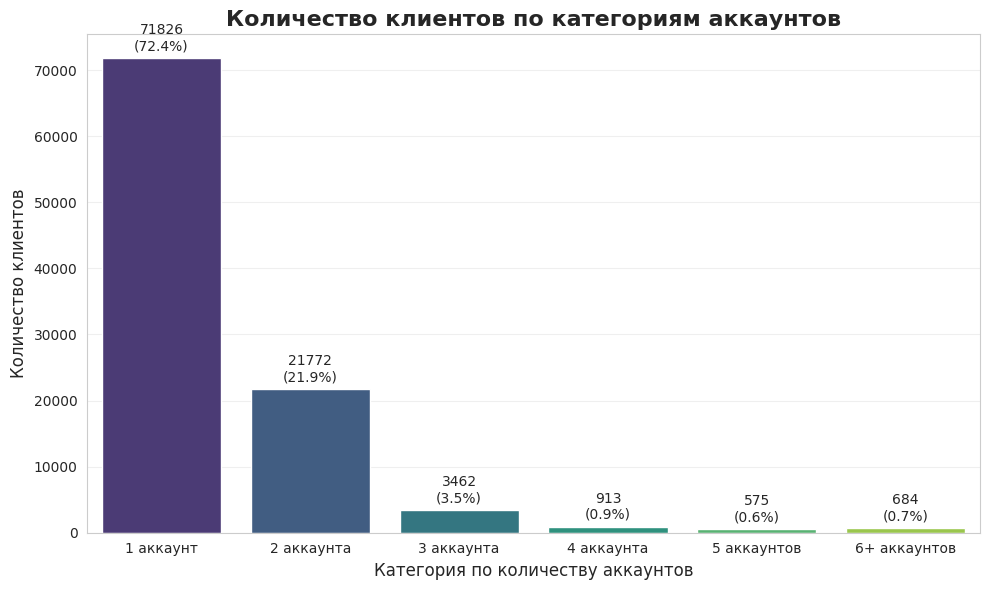


АНАЛИЗ ВЫБРОСОВ:
Клиентов с аномальным количеством аккаунтов (выбросы): 2172 (2.19%)
Минимальное количество аккаунтов среди выбросов: 4
Максимальное количество аккаунтов среди выбросов: 34


In [ ]:
# 1. Создаем DataFrame с количеством аккаунтов на клиента
accounts_per_client = df_filtered_1.groupby('client_rk')['account_rk'].nunique().reset_index()
accounts_per_client.columns = ['client_rk', 'account_count']

# 2. Создаем категории на основе количества аккаунтов
def categorize_accounts(count):
    if count == 1:
        return "1 аккаунт"
    elif count == 2:
        return "2 аккаунта"
    elif count == 3:
        return "3 аккаунта"
    elif count == 4:
        return "4 аккаунта"
    elif count == 5:
        return "5 аккаунтов"
    else:
        return "6+ аккаунтов"

accounts_per_client['account_category'] = accounts_per_client['account_count'].apply(categorize_accounts)

# 3. Порядок категорий для правильной сортировки
category_order = ["1 аккаунт", "2 аккаунта", "3 аккаунта", "4 аккаунта", "5 аккаунтов", "6+ аккаунтов"]
accounts_per_client['account_category'] = pd.Categorical(
    accounts_per_client['account_category'],
    categories=category_order,
    ordered=True
)

# 4. Создаем DataFrame для статистики (чтобы избежать предупреждения observed=False)
category_stats = accounts_per_client.groupby('account_category', observed=False).size().reset_index(name='count')

# 5. Статистика по категориям
print("РАСПРЕДЕЛЕНИЕ КЛИЕНТОВ ПО КАТЕГОРИЯМ АККАУНТОВ:")

total_clients = len(accounts_per_client)
for _, row in category_stats.iterrows():
    percentage = (row['count'] / total_clients) * 100
    print(f"{row['account_category']}: {row['count']} клиентов ({percentage:.2f}%)")

# 6. Создаем график без предупреждений
plt.figure(figsize=(10, 6))

# Используем hue и legend=False, чтобы избежать предупреждения о palette
barplot = sns.barplot(data=category_stats, x='account_category', y='count',
                      hue='account_category', palette='viridis', legend=False,
                      order=category_order)

# Добавляем заголовок и подписи
plt.title('Количество клиентов по категориям аккаунтов', fontsize=16, fontweight='bold')
plt.xlabel('Категория по количеству аккаунтов', fontsize=12)
plt.ylabel('Количество клиентов', fontsize=12)

# Добавляем значения на столбцы
for i, (category, count) in enumerate(zip(category_stats['account_category'], category_stats['count'])):
    percentage = (count / total_clients) * 100
    plt.text(i, count + max(category_stats['count']) * 0.01, f'{count}\n({percentage:.1f}%)',
             ha='center', va='bottom', fontsize=10)

# Настраиваем сетку
plt.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


# 6. Анализ выбросов IQR метод (IQR разница между 75- м 25-м перцентилями. )
print(f"\nАНАЛИЗ ВЫБРОСОВ:")

Q1 = accounts_per_client['account_count'].quantile(0.25)
Q3 = accounts_per_client['account_count'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR # нижняя граница
upper_bound = Q3 + 1.5 * IQR # верхняя граница
# все что вне границ выбросы

outliers = accounts_per_client[(accounts_per_client['account_count'] < lower_bound) |
                               (accounts_per_client['account_count'] > upper_bound)] # ищем клинтов у которых аномально много аккаунтов

print(f"Клиентов с аномальным количеством аккаунтов (выбросы): {len(outliers)} ({len(outliers)/len(accounts_per_client)*100:.2f}%)")
if len(outliers) > 0:
    print(f"Минимальное количество аккаунтов среди выбросов: {outliers['account_count'].min()}")
    print(f"Максимальное количество аккаунтов среди выбросов: {outliers['account_count'].max()}")


У большинства клиентов 71 826 (72,4%) 1 аккаунт, т.к. у меня нет возможности выяснить причину появления нескольких аккаунтов, то для чистоты эксперимента оставляю только клиентов с 1 аккаунтом.

In [ ]:
clients_with_one_account = accounts_per_client[accounts_per_client['account_count'] == 1]['client_rk'].tolist()

# Создаем новый датасет, фильтруя исходный по этим клиентам
df_one_account_clients = df_filtered_1[df_filtered_1['client_rk'].isin(clients_with_one_account)]

print(f"Создан датасет с клиентами, у которых 1 аккаунт")
print(f"Размер нового датасета: {df_one_account_clients.shape}")
print(f"Уникальных клиентов: {df_one_account_clients['client_rk'].nunique()}")

Создан датасет с клиентами, у которых 1 аккаунт
Размер нового датасета: (493268, 46)
Уникальных клиентов: 71826


In [ ]:
df_one_account_clients.reset_index(drop=True)

,account_rk,client_rk,order_rk,loyalty_program_type_nm,bundle_nm,order_type_cd,order_status_cd,party_first_order_dt,party_first_order_type_dt,created_dttm,...,time_zone_cd,last_used_product_cd,first_used_product_cd,mobile_phone_operator_nm,marital_status_cd,education_level_cd,birth_place,gender_cd,last_sms_dt,last_session_dttm
0,209c833731e84d21b5b7e673e0fb848749b9e7d29cda64...,f4959ffb27271192727050953ecb27a8a8a38af413f3d8...,fe1c6ce13774d102c655df4c01d54c34d495ef3d4c7e63...,Bravo,Pro,AIR,SUC,2019-12-12,2019-12-12,2024-11-01 12:39:13.457847,...,003,MPL,MPL,Тинькофф Мобайл,NaN,NaN,ГОР ЯРОСЛАВЛЬ,M,2024-07-02,2024-11-06 19:42:52
1,2bbcde706bead3731f2dc8dfbeefb4e12b42ac63e3d8ba...,7025587bc277176246bc44dff396036552a41d5a92d6aa...,98cb83b7748cdf77e43a50f56335a376b51fb767893303...,Tinkoff Black Premium,Premium,HOT,SUC,2019-11-21,2023-09-20,2024-04-09 21:27:01.394000,...,003,INV,IBN,TELE2,MAR,GRD,Р П ВЛАДИМИР 30,M,2024-06-26,2024-11-06 23:36:38
2,3133e7ae6698dcda9754d6a8b449782320260ff1259547...,1a2a4351a96099f9e49bbe2fc7236d41ac63b444176058...,b5e7909d8d7b902e4cdf268ebcbef6820c10b0ed75614b...,Tinkoff Black Premium,Premium,AIR,SUC,2019-02-18,2019-02-18,2024-02-06 11:50:47.558707,...,003,MPL,MPL,МегаФон,MAR,GRD,ГОР. МОСКВА,M,2024-07-15,2024-11-06 23:42:28
3,d46dfbb896f22579d9d46bda841ba4842a1d79ce9813eb...,eab9d7e6f59d4faa76c8690dd137dd51d88a2fba81a0cb...,4842efa215933e9d8f51f414a40aef0f9375d5a9b9c960...,Tinkoff Black,Pro,AIR,SUC,2022-07-22,2022-07-22,2024-07-07 12:05:20.600301,...,003,MPL,MPL,TELE2,NaN,NaN,BUKHARA REGION,M,2024-06-18,2024-11-06 23:49:38
4,ab2f0a402e75b6808f4375229213645fdc6e07a31c4f06...,ebcaa1cc435586f80c02b1f7b24acbf7a29ace16b8c6e4...,93184cf9542a3dec6bbb29b88a3ff9536a02287637eae2...,All Airlines Premium Кредитный,Premium,AIR,SUC,2023-09-26,2023-09-26,2024-04-15 14:44:56.365633,...,003,MPL,IPL,Билайн,MAR,GRD,ГОР ИВАНОВО,M,2024-06-25,2024-11-06 23:28:28
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
493263,a902667e8a484f80147e2048cfb80f8aa6166f9aebe90b...,1d81bb6d3fdccde93852e8d2830df2378b218e865a6054...,fc3b905517c9c11157cba6f424ee4aed5af4bd03d2da69...,All Airlines,NaN,HOT,SUC,2021-10-22,2022-11-20,2024-08-30 16:20:35.445000,...,3,MPL,MPL,Билайн,MAR,NaN,ГОР МОСКВА,F,2024-06-13,2024-11-06 10:04:55
493264,089ef64bb5fa473d1465156c6f386d8e4ef7f2d71f1fec...,2c4d34efa362643136b1d8cdb9b9c270b3b17da06a8bac...,a221eac6a2a1199cca198541f766c6655c88b2d089b7d3...,Tinkoff Black,NaN,AIR,SUC,2018-08-20,2022-07-24,2024-09-30 14:11:21.998551,...,3,IPL,IBN,МТС,DIV,GRD,ГОР НОРИЛЬСК КРАСНОЯРСКОГО КР,F,2024-09-25,2024-10-30 20:26:07
493265,52fe652d6665b1f0cc75132af0ef6622495d0d711e1547...,25038af02fd0a8ee9320fc05c4dccbdfb4f0bb9ec854ad...,58a7b3a5489fcf1a140437eab1bce478274018854dd54d...,All Airlines,Pro,AIR,SUC,2019-05-18,2021-02-22,2024-05-03 17:01:28.380710,...,3,MPL,MPL,Тинькофф Мобайл,MAR,GRD,НОВОСИБИРСК,M,2024-09-15,2024-11-06 23:46:10
493266,e10b8a165641d85e4c9b624a352b5e572e83182e8d2adb...,5e0ec81cd80b3aff6441b7734bfb6b20ac45150a99b973...,8b743a6b14506b637828b871e26148cdcec39321a15284...,Tinkoff Black Private,Private,AIR,SUC,2021-05-04,2021-05-04,2024-03-13 06:44:36.772181,...,12,INV,INV,Билайн,NaN,NaN,ГОР ПЕТРОПАВЛОВСК-КАМЧАТСКИЙ,M,2024-06-29,2024-11-06 10:55:12


#Далее работать с df_one_account_clients

Сейчас в датасете представлены клиенты с уникальным идентификатором и единственным аккаунтом. У каждого клиента — один или несколько успешных заказов (статус SUC). Определим, сколько клиентов совершили более одного заказа.



СТАТИСТИКИ КОЛИЧЕСТВА ЗАКАЗОВ НА КЛИЕНТА


Всего уникальных клиентов: 71,826
Всего заказов в датасете: 493,268
Максимальное число заказов у одного клиента: 349
Среднее число заказов на клиента: 6.87
Медианное число заказов на клиента: 5.00


СВОДНАЯ ТАБЛИЦА ПО КАТЕГОРИЯМ КЛИЕНТОВ


client_category  clients_count percentage  total_orders  avg_orders
        1 заказ           4427      6.16%          4427    1.000000
       2 заказа           5891      8.20%         11782    2.000000
       3 заказа           7381     10.28%         22143    3.000000
    4-5 заказов          20472     28.50%         92931    4.539420
   6-10 заказов          23296     32.43%        172387    7.399854
    10+ заказов          10359     14.42%        189598   18.302732


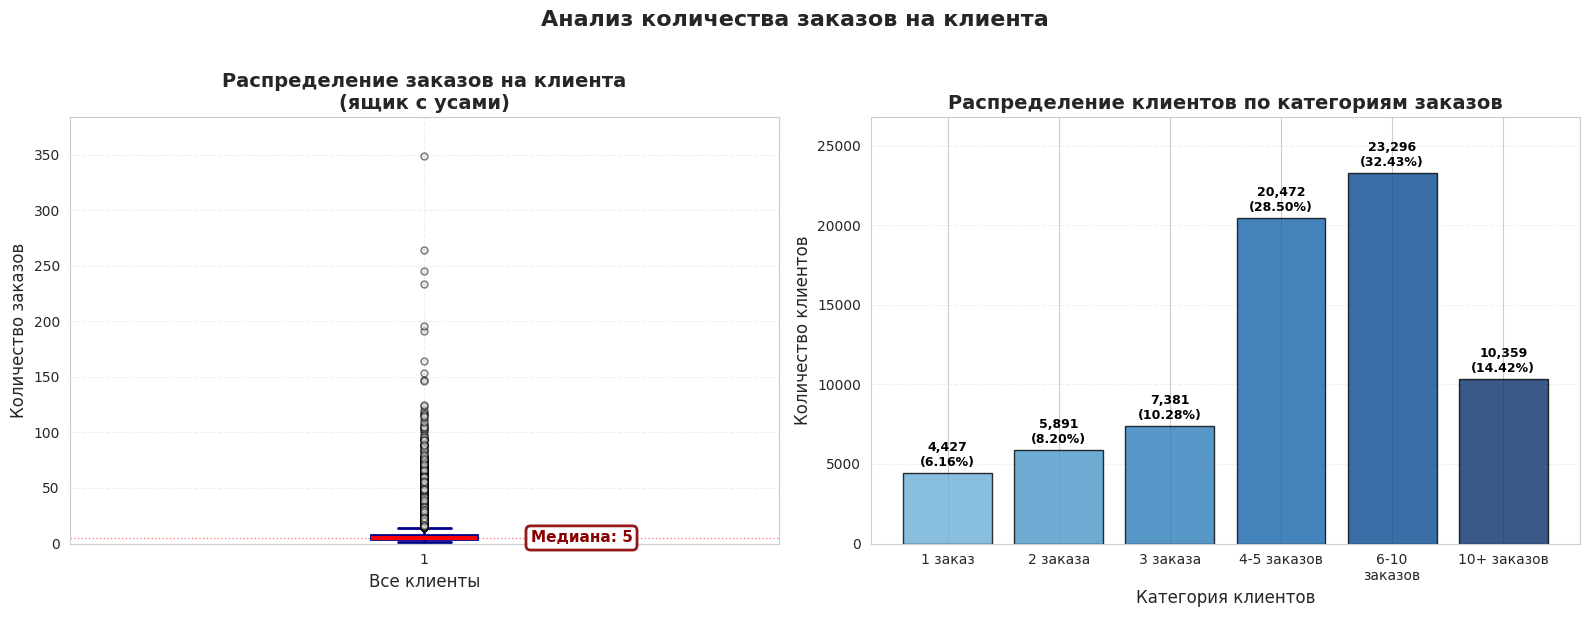

ДОПОЛНИТЕЛЬНЫЕ СТАТИСТИКИ
Q1 (25-й перцентиль): 4 заказов
Медиана (50-й перцентиль): 5 заказов
Q3 (75-й перцентиль): 8 заказов
Мода: 5 заказов (встречается у 11,043 клиентов, 15.4%)
Межквартильный размах (IQR): 4 заказов
Размах (диапазон): от 1 до 349 заказов
Выбросы (клиенты с >14 заказов): 5,248 клиентов (7.31%)
Максимальное количество заказов у выброса: 349


In [ ]:
# Создаем DataFrame с количеством заказов на клиента
orders_per_client = df_one_account_clients.groupby('client_rk')['order_rk'].nunique().reset_index()
orders_per_client.columns = ['client_rk', 'orders_count']

# Основные статистики
print("\n")
print("СТАТИСТИКИ КОЛИЧЕСТВА ЗАКАЗОВ НА КЛИЕНТА")
print("\n")
print(f"Всего уникальных клиентов: {orders_per_client['client_rk'].nunique():,}")
print(f"Всего заказов в датасете: {df_one_account_clients['order_rk'].nunique():,}")
print(f"Максимальное число заказов у одного клиента: {orders_per_client['orders_count'].max():,}")
print(f"Среднее число заказов на клиента: {orders_per_client['orders_count'].mean():.2f}")
print(f"Медианное число заказов на клиента: {orders_per_client['orders_count'].median():.2f}")

# Вычисляем моду (наиболее часто встречающееся количество заказов)
mode_result = orders_per_client['orders_count'].mode()
if len(mode_result) > 0:
    # Если есть несколько мод, берем первую
    mode_value = mode_result.iloc[0]
    mode_count = (orders_per_client['orders_count'] == mode_value).sum()
else:
    mode_value = None
    mode_count = 0

# Создаем категории клиентов
orders_per_client['client_category'] = pd.cut(
    orders_per_client['orders_count'],
    bins=[0, 1, 2, 3, 5, 10, float('inf')],
    labels=['1 заказ', '2 заказа', '3 заказа', '4-5 заказов', '6-10 заказов', '10+ заказов']
)

# Сводная таблица по категориям
category_summary = orders_per_client.groupby('client_category', observed=False).agg(
    clients_count=('client_rk', 'count'),
    percentage=('client_rk', lambda x: f"{len(x) / orders_per_client.shape[0] * 100:.2f}%"),
    total_orders=('orders_count', 'sum'),
    avg_orders=('orders_count', 'mean')
).reset_index()

print("\n")
print("СВОДНАЯ ТАБЛИЦА ПО КАТЕГОРИЯМ КЛИЕНТОВ")
print("\n")
print(category_summary.to_string(index=False))

# Создаем фигуру с двумя графиками
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Ящик с усами (boxplot) - УПРОЩЕННАЯ версия с ТОЛЬКО медианой
boxplot = axes[0].boxplot(orders_per_client['orders_count'],
                          vert=True,
                          patch_artist=True,
                          boxprops=dict(facecolor='lightblue', color='darkblue', linewidth=2),
                          whiskerprops=dict(color='darkblue', linewidth=2),
                          capprops=dict(color='darkblue', linewidth=2),
                          medianprops=dict(color='red', linewidth=3),
                          flierprops=dict(marker='o', markerfacecolor='lightgray', markersize=5, alpha=0.5))

axes[0].set_title('Распределение заказов на клиента\n(ящик с усами)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Количество заказов', fontsize=12)
axes[0].set_xlabel('Все клиенты', fontsize=12)
axes[0].grid(True, alpha=0.3, linestyle='--')

# Вычисляем статистики
stats = orders_per_client['orders_count'].describe()
q1, q2, q3 = stats['25%'], stats['50%'], stats['75%']
min_val, max_val = stats['min'], stats['max']
iqr = q3 - q1
mean_value = orders_per_client['orders_count'].mean()

# Определяем выбросы (более 1.5 * IQR от квартилей)
upper_whisker = min(max_val, q3 + 1.5 * iqr)

# ТОЛЬКО ОДНА АННОТАЦИЯ - МЕДИАНА
axes[0].text(1.15, q2, f'Медиана: {q2:.0f}',
             va='center', ha='left', fontsize=11, fontweight='bold',
             color='darkred',
             bbox=dict(boxstyle="round,pad=0.3", facecolor="white",
                      edgecolor='darkred', alpha=0.9, linewidth=2))

# Можно добавить только линию медианы для наглядности (опционально)
axes[0].axhline(y=q2, color='red', linestyle=':', alpha=0.5, linewidth=1)

# Настраиваем пределы оси Y для лучшего отображения
y_margin = (max_val - min_val) * 0.1
axes[0].set_ylim([max(0, min_val - y_margin*0.5), max_val + y_margin])

# 2. Распределение клиентов по категориям заказов
categories = category_summary['client_category'].astype(str)
clients = category_summary['clients_count']

# Создаем цветовую схему для столбцов
colors = plt.cm.Blues(np.linspace(0.5, 1, len(categories)))

# ДОБАВЛЯЕМ ПРОБЕЛЫ В ДЛИННЫХ НАДПИСЯХ ДЛЯ КАТЕГОРИЙ
category_summary['client_category_display'] = category_summary['client_category'].astype(str)
# Заменяем переносом строки для длинных категорий
category_summary.loc[category_summary['client_category'] == '6-10 заказов', 'client_category_display'] = '6-10\nзаказов'

# Обновляем категории для отображения
categories_display = category_summary['client_category_display']

bars = axes[1].bar(categories_display, clients, edgecolor='black', alpha=0.8, color=colors)
axes[1].set_title('Распределение клиентов по категориям заказов', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Категория клиентов', fontsize=12)
axes[1].set_ylabel('Количество клиентов', fontsize=12)
axes[1].grid(True, alpha=0.3, axis='y', linestyle='--')

# УВЕЛИЧИВАЕМ ВЕРХНИЙ ПРЕДЕЛ ОСИ Y для гистограммы
max_clients = max(clients)
axes[1].set_ylim([0, max_clients * 1.15])  # Добавляем 15% сверху для надписей

# Добавляем значения над столбцами и проценты
for bar, count, percentage, cat_display in zip(bars, clients, category_summary['percentage'], categories_display):
    height = bar.get_height()
    # Высота текста - немного выше столбца
    text_y = height + max_clients * 0.01

    # Для категории с переносом строки делаем многострочную надпись
    if '\n' in cat_display:
        text_str = f'{count:,}\n({percentage})'
        va = 'bottom'
    else:
        text_str = f'{count:,}\n({percentage})'
        va = 'bottom'

    axes[1].text(bar.get_x() + bar.get_width()/2., text_y,
                text_str,
                ha='center', va=va, fontsize=9, fontweight='bold',
                color='black')

# Настраиваем внешний вид второго графика
axes[1].set_axisbelow(True)  # Сетка под столбцами

# Настройка общего вида
plt.suptitle('Анализ количества заказов на клиента', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Выводим дополнительные статистики

print("ДОПОЛНИТЕЛЬНЫЕ СТАТИСТИКИ")

print(f"Q1 (25-й перцентиль): {q1:.0f} заказов")
print(f"Медиана (50-й перцентиль): {q2:.0f} заказов")
print(f"Q3 (75-й перцентиль): {q3:.0f} заказов")
if mode_value is not None:
    print(f"Мода: {mode_value:.0f} заказов (встречается у {mode_count:,} клиентов, {mode_count/orders_per_client.shape[0]*100:.1f}%)")
else:
    print("Мода: не определена")
print(f"Межквартильный размах (IQR): {iqr:.0f} заказов")
print(f"Размах (диапазон): от {min_val:.0f} до {max_val:.0f} заказов")

# Если есть несколько мод, покажем их все
if len(mode_result) > 1:
    print(f"\nВсе значения моды (несколько): {list(mode_result)}")

# Статистика по выбросам
outliers = orders_per_client[orders_per_client['orders_count'] > upper_whisker]['orders_count']
if len(outliers) > 0:
    print(f"Выбросы (клиенты с >{upper_whisker:.0f} заказов): {len(outliers):,} клиентов ({len(outliers)/orders_per_client.shape[0]*100:.2f}%)")
    if len(outliers) > 0:
        print(f"Максимальное количество заказов у выброса: {outliers.max():.0f}")

***Выводы: в среднем каждый клиент делает 6,87 заказов, это говорит о хорошей повторной покупке, медиана 5, и есть клиенты с очень большим количеством заказов (выбросы). Большинство клиентов делает больше 4 заказов. Выбросы определялись по формуле выбросы = значения > Q3 + 1.5 × IQR, где IQR показывает разброс типичных значений.***

Т.к. нам нужна информация о самом первом заказе клиента, посмотрим какая информация есть в столбцах party_first_order_dt (дата первого заказа)

In [ ]:
# Подсчет клиентов, у которых есть party_first_order_dt
clients_with_first_order = df_one_account_clients[
    df_one_account_clients['party_first_order_dt'].notna()
]['client_rk'].nunique()

# Подсчет клиентов, у которых есть party_first_order_type_dt
clients_with_order_type = df_one_account_clients[
    df_one_account_clients['party_first_order_type_dt'].notna()
]['client_rk'].nunique()

# Подсчет клиентов, у которых есть оба поля
clients_with_both = df_one_account_clients[
    df_one_account_clients['party_first_order_dt'].notna() &
    df_one_account_clients['party_first_order_type_dt'].notna()
]['client_rk'].nunique()

# Общее количество клиентов в датасете
total_clients = df_one_account_clients['client_rk'].nunique()

print("="*60)
print("ИНФОРМАЦИЯ О ПЕРВЫХ ЗАКАЗАХ КЛИЕНТОВ")
print("="*60)
print(f"Всего клиентов в датасете: {total_clients}")
print(f"Клиентов с party_first_order_dt: {clients_with_first_order} ({clients_with_first_order/total_clients*100:.2f}%)")
print(f"Клиентов с party_first_order_type_dt: {clients_with_order_type} ({clients_with_order_type/total_clients*100:.2f}%)")
print(f"Клиентов с обоими полями: {clients_with_both} ({clients_with_both/total_clients*100:.2f}%)")


ИНФОРМАЦИЯ О ПЕРВЫХ ЗАКАЗАХ КЛИЕНТОВ
Всего клиентов в датасете: 71826
Клиентов с party_first_order_dt: 71826 (100.00%)
Клиентов с party_first_order_type_dt: 71826 (100.00%)
Клиентов с обоими полями: 71826 (100.00%)


Оба столбца с датой первого заказа и датой первого заказа определенного типа полностью заполнены.

In [ ]:
# Получаем уникальные даты первых заказов
first_order_dates = df_one_account_clients['party_first_order_dt'].dropna().unique()
first_order_dates = pd.Series(first_order_dates).sort_values()

print("="*60)
print("АНАЛИЗ ДАТ ПЕРВЫХ ЗАКАЗОВ")
print("="*60)
print(f"Всего записей с датами: {df_one_account_clients['party_first_order_dt'].notna().sum()}")
print(f"Уникальных дат: {len(first_order_dates)}")
print(f"\nПериод дат:")
print(f"  Самая ранняя дата: {first_order_dates.min()}")
print(f"  Самая поздняя дата: {first_order_dates.max()}")
print(f"  Период: {first_order_dates.max() - first_order_dates.min()}")


АНАЛИЗ ДАТ ПЕРВЫХ ЗАКАЗОВ
Всего записей с датами: 493268
Уникальных дат: 2487

Период дат:
  Самая ранняя дата: 2017-09-26 00:00:00
  Самая поздняя дата: 2024-11-06 00:00:00
  Период: 2598 days 00:00:00


Отфильтруем данные: оставим только тех клиентов, которые сделали первый заказ не ранее 1 января 2024 года. Это обеспечит актуальность демографических и иных показателей для анализа. Кроме того, с 2017 года были значимые события, например COVID

In [ ]:
df_2024_orders = df_one_account_clients[
    df_one_account_clients['party_first_order_dt'].dt.year == 2024
].copy()

print("="*60)
print("РЕЗУЛЬТАТ ФИЛЬТРАЦИИ (ЗАКАЗЫ 2024 ГОДА)")
print("="*60)
print(f"Исходный датасет: {len(df_one_account_clients)} строк")
print(f"Отфильтрованный датасет (2024 год): {len(df_2024_orders)} строк")
print(f"Удалено строк: {len(df_one_account_clients) - len(df_2024_orders)}")
print(f"\nДиапазон дат в отфильтрованном датасете:")
print(f"  Минимальная: {df_2024_orders['party_first_order_dt'].min()}")
print(f"  Максимальная: {df_2024_orders['party_first_order_dt'].max()}")

РЕЗУЛЬТАТ ФИЛЬТРАЦИИ (ЗАКАЗЫ 2024 ГОДА)
Исходный датасет: 493268 строк
Отфильтрованный датасет (2024 год): 65695 строк
Удалено строк: 427573

Диапазон дат в отфильтрованном датасете:
  Минимальная: 2024-01-01 00:00:00
  Максимальная: 2024-11-06 00:00:00


In [ ]:
# Подсчет количества уникальных клиентов
unique_clients_2024 = df_2024_orders['client_rk'].nunique()
total_clients = df_one_account_clients['client_rk'].nunique()

print(f"\n{'='*60}")
print(f"ИНФОРМАЦИЯ О КЛИЕНТАХ:")
print(f"{'='*60}")
print(f"Клиентов с заказами в 2024 году: {unique_clients_2024}")
print(f"Процент от всех клиентов: {unique_clients_2024/total_clients*100:.2f}%")


ИНФОРМАЦИЯ О КЛИЕНТАХ:
Клиентов с заказами в 2024 году: 10334
Процент от всех клиентов: 14.39%


ИТОГО в 2024 году 10 334 клиента сделали свой первый заказ.

Проанализируем какие значения содержит столбец статус заказа (order_type_cd)

In [ ]:
unique_values = df_2024_orders['order_type_cd'].dropna().unique()
print(f"Найдено {len(unique_values)} уникальных значений:")
for i, val in enumerate(sorted(unique_values), 1):
    print(f"{i:3d}. '{val}'")

Найдено 2 уникальных значений:
  1. 'AIR'
  2. 'HOT'


 В данных только два уникальных значения AIR и HOT.

Проанализируем как заказы распределены по типам.

In [ ]:
print("="*60)
print("РАСПРЕДЕЛЕНИЕ ТИПОВ ЗАКАЗОВ AIR И HOT")
print("="*60)

# Подсчет количества каждого типа
air_count = (df_2024_orders['order_type_cd'] == 'AIR').sum()
hot_count = (df_2024_orders['order_type_cd'] == 'HOT').sum()
null_count = df_2024_orders['order_type_cd'].isna().sum()

total = len(df_2024_orders)

print(f"Всего записей: {total}")
print(f"\n РАСПРЕДЕЛЕНИЕ:")
print(f"  AIR: {air_count} ({air_count/total*100:.2f}%)")
print(f"  HOT: {hot_count} ({hot_count/total*100:.2f}%)")


РАСПРЕДЕЛЕНИЕ ТИПОВ ЗАКАЗОВ AIR И HOT
Всего записей: 65695

 РАСПРЕДЕЛЕНИЕ:
  AIR: 51450 (78.32%)
  HOT: 14245 (21.68%)


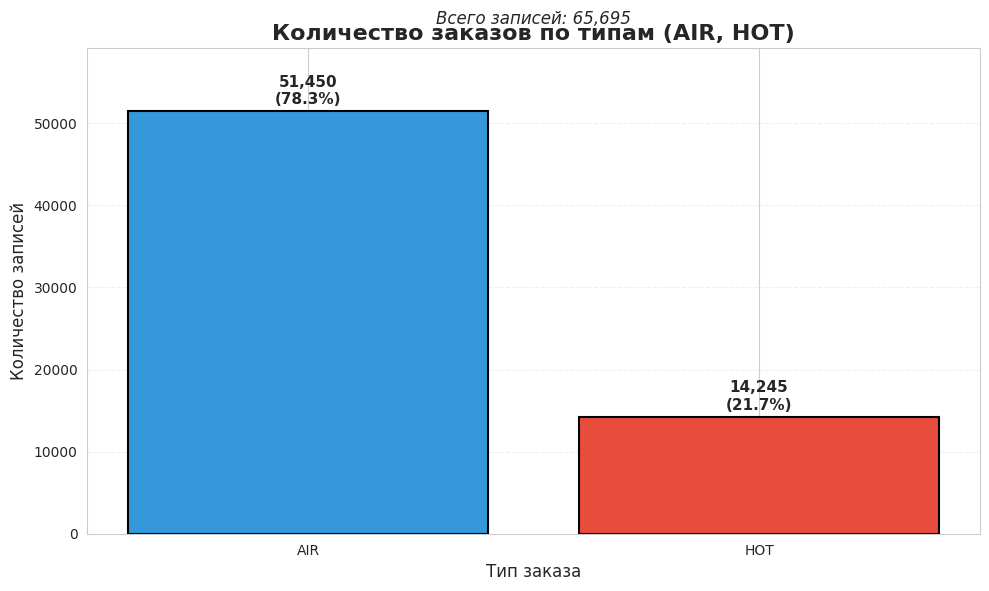

In [ ]:
# СОЗДАНИЕ СТОЛБЧАТОЙ ДИАГРАММЫ
fig, ax = plt.subplots(figsize=(10, 6))

# Подготовка данных для графика
labels = []
values = []
colors = []

# Добавляем только непустые категории
if air_count > 0:
    labels.append('AIR')
    values.append(air_count)
    colors.append('#3498db')  # синий
if hot_count > 0:
    labels.append('HOT')
    values.append(hot_count)
    colors.append('#e74c3c')  # красный
#if null_count > 0:
#    labels.append('Пустые')
#    values.append(null_count)
#    colors.append('#2ecc71')  # зеленый

# Построение столбчатой диаграммы
bars = ax.bar(labels, values, color=colors, edgecolor='black', linewidth=1.5)
ax.set_title('Количество заказов по типам (AIR, HOT)', fontsize=16, fontweight='bold')
ax.set_ylabel('Количество записей', fontsize=12)
ax.set_xlabel('Тип заказа', fontsize=12)
ax.grid(True, axis='y', alpha=0.3, linestyle='--')

# Добавляем значения на столбцы
max_value = max(values) if values else 1
for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width()/2.,
        height + max_value * 0.01,
        f'{int(height):,}\n({height/total*100:.1f}%)',
        ha='center',
        va='bottom',
        fontsize=11,
        fontweight='bold'
    )

# Добавляем подписи значений над столбцами
ax.set_ylim(0, max_value * 1.15)  # добавляем место для подписей

# Добавляем общее количество в заголовок
ax.text(0.5, 1.05, f'Всего записей: {total:,}',
        transform=ax.transAxes, ha='center', fontsize=12, style='italic')

plt.tight_layout()
plt.show()

Распределение не равномерное

Оставляем в данных информацию только о самом первом заказе

In [ ]:
df_clients_first_order_2024 = df_one_account_clients[
    df_one_account_clients['party_first_order_dt'].dt.year == 2024
].copy()

print("="*60)
print("ДАТАСЕТ С КЛИЕНТАМИ (ПЕРВЫЙ ЗАКАЗ В 2024 ГОДУ)")
print("="*60)
print(f"Размер датасета: {df_clients_first_order_2024.shape}")
print(f"Количество строк: {len(df_clients_first_order_2024)}")
print(f"Уникальных клиентов: {df_clients_first_order_2024['client_rk'].nunique()}")
print(f"Уникальных заказов: {df_clients_first_order_2024['order_rk'].nunique()}")
print(f"\nДиапазон дат первых заказов:")
print(f"  От: {df_clients_first_order_2024['party_first_order_dt'].min()}")
print(f"  До: {df_clients_first_order_2024['party_first_order_dt'].max()}")


ДАТАСЕТ С КЛИЕНТАМИ (ПЕРВЫЙ ЗАКАЗ В 2024 ГОДУ)
Размер датасета: (65695, 46)
Количество строк: 65695
Уникальных клиентов: 10334
Уникальных заказов: 65695

Диапазон дат первых заказов:
  От: 2024-01-01 00:00:00
  До: 2024-11-06 00:00:00


In [ ]:
# Для каждого клиента находим первый заказ
first_orders = df_clients_first_order_2024.loc[
    df_clients_first_order_2024.groupby('client_rk')['party_first_order_dt'].idxmin()
].copy()

print("="*60)
print("ПЕРВЫЕ ЗАКАЗЫ КЛИЕНТОВ В 2024 ГОДУ")
print("="*60)
print(f"Количество первых заказов: {len(first_orders)}")
print(f"\nДиапазон дат:")
print(f"  Ранний: {first_orders['party_first_order_dt'].min()}")
print(f"  Поздний: {first_orders['party_first_order_dt'].max()}")
print(f"  Период: {first_orders['party_first_order_dt'].max() - first_orders['party_first_order_dt'].min()}")



ПЕРВЫЕ ЗАКАЗЫ КЛИЕНТОВ В 2024 ГОДУ
Количество первых заказов: 10334

Диапазон дат:
  Ранний: 2024-01-01 00:00:00
  Поздний: 2024-11-06 00:00:00
  Период: 310 days 00:00:00


In [ ]:
print(f"Количество строк в датасете: {first_orders.shape[0]}")

Количество строк в датасете: 10334


В датасете first_orders осталось информация только о первом заказе каждого клиента. Всего таких заказов 10 334

Для моделирования поведения нового клиента, мы должны использовать только ту информацию которую знаем до совершения покупки. Это демографические данные, среднемесячный доход, разрешенная коммуникация и т.п.

In [ ]:
print("Пропуски по столбцам (отсортировано по убыванию):")


missing_info = pd.DataFrame({
    'Пропуски': first_orders.isnull().sum(),                          # создаем датафрейм булевых значенией, True-где значение пропущено и суммируем их по каждому столбцу
    'Процент': (first_orders.isnull().sum() / len(first_orders) * 100).round(2)}) # пропуски/общее количество строк в df


missing_sorted = missing_info.sort_values('Процент', ascending=False) # сортируем по проценту пропусков (убывание)

print(missing_sorted)

# Общая информация
total_missing = missing_info['Пропуски'].sum()
total_cells = first_orders.size
print(f"Всего строк в датасете: {len(first_orders)}")
print(f"Всего пропусков: {total_missing}")
print(f"Процент пропусков в датасете: {(total_missing/total_cells*100):.2f}%")

Пропуски по столбцам (отсортировано по убыванию):
                             Пропуски  Процент
hotel_country                    7328    70.91
hotel_city                       7328    70.91
book_end_dttm                    7281    70.46
education_level_cd               6527    63.16
marital_status_cd                5763    55.77
lvn_city_nm                      4597    44.48
bundle_nm                        4254    41.17
children_cnt                     3814    36.91
monthly_income_amt               3417    33.07
avia_arr_city                    3053    29.54
avia_dep_city                    3053    29.54
order_item_cnt                   3053    29.54
promo_code_discount_amt          3034    29.36
loyalty_accrual_rub_amt          2621    25.36
lvn_state_nm                     1240    12.00
parent_meeting_region_nm          637     6.16
gender_cd                         356     3.44
month_beginning_balance_rub       333     3.22
last_sms_dt                       154     1.49
last_sms_s

##*Определю* столбцы, которые по смыслу не могут участвовать в построении модели

**Будут удалены:**

***Модель их запомнить, но не перенесет на новых клиентов:***

account_rk — уникальный ID аккаунта

client_rk — уникальный ID клиента

order_rk — уникальный ID заказа

Эти признаки напрямую указывают на тип продукта:
***Текст, выделенный полужирным шрифтом***
last_used_product_cd — клиент уже выбрал продукт

first_used_product_cd — информация о предыдущем выборе, а мы и так выбрали информацию о первом продукте (будет дублировать)


***Признаки, которые известны только после бронирования, т.е. характеристики уже совершенного заказа. Для нового клиента их не будет***

order_status_cd

created_dttm

book_start_dttm

local_book_start_dttm

book_end_dttm

hotel_country

hotel_city

avia_dep_city

avia_arr_city

order_item_cnt

promo_code_discount_amt

loyalty_accrual_rub_amt

nominal_price_eur_amt

nominal_price_rub_amt

Признаки коммуникационной истории (цель — первый продукт)

***Если задача — предложить продукт новому клиенту без истории, удаляем:***

last_sms_dt

last_sms_success_flg

last_session_dttm

***Признаки с критичной пропущенностью***

education_level_cd (64% пропусков)

marital_status_cd (56% пропусков)

children_cnt (37% пропусков)

lvn_city_nm (45% пропусков)

hotel_country / hotel_city (там 71% пропусков)

***Не несут смысловой нагрузки***

time_zone_cd и time_zone_delta_tm

##Проанализирую, какую информацию содержат категориальные столбцы

bundle_nm - подписка, применившаяся к оплате Pro/Premium

In [ ]:
unique_values = first_orders['bundle_nm'].dropna().unique()
print(f"Найдено {len(unique_values)} уникальных значений:")
for i, val in enumerate(sorted(unique_values), 1):
    print(f"{i:3d}. '{val}'")

Найдено 6 уникальных значений:
  1. 'Premium'
  2. 'Private'
  3. 'Pro'
  4. 'Team Pro'
  5. 'Tinkoff Premium'
  6. 'Tinkoff Pro'


Программы лояльности

In [ ]:
unique_values_lp = first_orders['loyalty_program_type_nm'].dropna().unique()
print(f"Найдено {len(unique_values_lp)} уникальных значений:")
for i, val in enumerate(sorted(unique_values_lp), 1):
    print(f"{i:3d}. '{val}'")

Найдено 25 уникальных значений:
  1. 'AliExpress'
  2. 'AliExpressDebit'
  3. 'All Airlines'
  4. 'All Airlines Premium'
  5. 'All Airlines Premium Кредитный'
  6. 'AllAirLinesDebit'
  7. 'Bravo'
  8. 'Lamoda'
  9. 'Lukoil'
 10. 'S7'
 11. 'S7 Tinkoff Premium'
 12. 'S7 Tinkoff Premium Кредитный'
 13. 'S7Debit'
 14. 'Tinkoff Black'
 15. 'Tinkoff Black Premium'
 16. 'Tinkoff Black Private'
 17. 'Tinkoff Black Shared'
 18. 'Tinkoff Drive'
 19. 'Tinkoff Drive Debit'
 20. 'Tinkoff Platinum'
 21. 'Tinkoff Platinum Premium'
 22. 'Tinkoff Platinum Private'
 23. 'WargamingBlitzDebit'
 24. 'WargamingTanksDebit'
 25. 'WargamingWarshipsDebit'


parent_meeting_region_nm - в каком регионе клиент получал карту

In [ ]:
unique_values_pmr = first_orders['parent_meeting_region_nm'].dropna().unique()
print(f"Найдено {len(unique_values_pmr)} уникальных значений:")
for i, val in enumerate(sorted(unique_values_pmr), 1):
    print(f"{i:3d}. '{val}'")

Найдено 347 уникальных значений:
  1. 'Абакан'
  2. 'Адлер'
  3. 'Алапаевск'
  4. 'Алатырь'
  5. 'Альметьевск'
  6. 'Анадырь'
  7. 'Анапа'
  8. 'Ангарск'
  9. 'Апатиты'
 10. 'Арзамас'
 11. 'Армавир'
 12. 'Арск'
 13. 'Артем'
 14. 'Архангельск'
 15. 'Архипо-Осиповка'
 16. 'Астрахань'
 17. 'Ачинск'
 18. 'Бавлы'
 19. 'Балаково'
 20. 'Балашов'
 21. 'Барда'
 22. 'Барнаул'
 23. 'Батайск'
 24. 'Белгород'
 25. 'Белебей'
 26. 'Белорецк'
 27. 'Белоярский'
 28. 'Бердск'
 29. 'Березники'
 30. 'Бийск'
 31. 'Биробиджан'
 32. 'Благовещенск'
 33. 'Богданович'
 34. 'Боровичи'
 35. 'Боровский'
 36. 'Бородино'
 37. 'Братск'
 38. 'Брянск'
 39. 'Буденновск'
 40. 'Бузулук'
 41. 'Буй'
 42. 'Буйнакск'
 43. 'Буланаш'
 44. 'Бураево'
 45. 'Великие Луки'
 46. 'Великий Новгород'
 47. 'Вельск'
 48. 'Верещагино'
 49. 'Верхний уфалей'
 50. 'Верхняя Пышма'
 51. 'Верхняя Салда'
 52. 'Владивосток'
 53. 'Владикавказ'
 54. 'Владимир'
 55. 'Волгоград'
 56. 'Волгодонск'
 57. 'Волжск'
 58. 'Вологда'
 59. 'Воркута'
 60. 'Ворон

регион проживания

In [ ]:
unique_values_ls = first_orders['lvn_state_nm'].dropna().unique()
print(f"Найдено {len(unique_values_ls)} уникальных значений:")
for i, val in enumerate(sorted(unique_values_ls), 1):
    print(f"{i:3d}. '{val}'")

Найдено 148 уникальных значений:
  1. '.'
  2. 'ISRAEL'
  3. 'АЛТАЙСКИЙ КРАЙ'
  4. 'АМУРСКАЯ ОБЛ'
  5. 'АО ХАНТЫ-МАНСИЙСКИЙ АВТОНОМНЫЙ ОКРУГ - ЮГРА'
  6. 'АО ЯМАЛО-НЕНЕЦКИЙ'
  7. 'АРХАНГЕЛЬСКАЯ ОБЛ'
  8. 'АСТРАХАНСКАЯ ОБЛ'
  9. 'БЕЛАРУСЬ'
 10. 'БЕЛГОРОДСКАЯ ОБЛ'
 11. 'БРЕСТСКАЯ ОБЛАСТЬ'
 12. 'БРЯНСКАЯ ОБЛ'
 13. 'ВЛАДИМИРСКАЯ ОБЛ'
 14. 'ВОЛГОГРАДСКАЯ ОБЛ'
 15. 'ВОЛОГОДСКАЯ ОБЛ'
 16. 'ВОРОНЕЖСКАЯ ОБЛ'
 17. 'Г МОСКВА'
 18. 'Г САНКТ-ПЕТЕРБУРГ'
 19. 'Г СЕВАСТОПОЛЬ'
 20. 'Г. МОСКВА'
 21. 'Г. САНКТ-ПЕТЕРБУРГ'
 22. 'ГОРОД МОСКВА'
 23. 'ГОРОД САНКТ-ПЕТЕРБУРГ'
 24. 'ЕВРЕЙСКАЯ АОБЛ'
 25. 'ЗАБАЙКАЛЬСКИЙ КРАЙ'
 26. 'ЗАПОРОЖСКАЯ ОБЛ'
 27. 'ИВАНОВСКАЯ'
 28. 'ИВАНОВСКАЯ ОБЛ'
 29. 'ИРКУТСКАЯ ОБЛ'
 30. 'КАБАРДИНО-БАЛКАРСКАЯ РЕСП'
 31. 'КАЛИНИНГРАДСКАЯ ОБЛ'
 32. 'КАЛУЖСКАЯ ОБЛ'
 33. 'КАМЧАТСКИЙ КРАЙ'
 34. 'КАРАЧАЕВО-ЧЕРКЕССКАЯ РЕСП'
 35. 'КЕМЕРОВСКАЯ'
 36. 'КЕМЕРОВСКАЯ ОБЛ'
 37. 'КЕМЕРОВСКАЯ ОБЛАСТЬ - КУЗБАСС'
 38. 'КЕМЕРОВСКАЯ ОБЛАСТЬ - КУЗБАСС ОБЛ'
 39. 'КИРОВСКАЯ ОБЛ'
 40. 'КОСТРОМСКАЯ ОБЛ'
 41. 'КРАЙ

Уровень образования

In [ ]:
unique_values_el = first_orders['education_level_cd'].dropna().unique()
print(f"Найдено {len(unique_values_el)} уникальных значений:")
for i, val in enumerate(sorted(unique_values_el), 1):
    print(f"{i:3d}. '{val}'")

Найдено 5 уникальных значений:
  1. 'ACD'
  2. 'GRD'
  3. 'PGR'
  4. 'SCH'
  5. 'UGR'


возраст

In [ ]:
unique_values_age = first_orders['age'].dropna().unique()
print(f"Найдено {len(unique_values_age)} уникальных значений:")
for i, val in enumerate(sorted(unique_values_age), 1):
    print(f"{i:3d}. '{val}'")

Найдено 72 уникальных значений:
  1. '14.0'
  2. '15.0'
  3. '16.0'
  4. '17.0'
  5. '18.0'
  6. '19.0'
  7. '20.0'
  8. '21.0'
  9. '22.0'
 10. '23.0'
 11. '24.0'
 12. '25.0'
 13. '26.0'
 14. '27.0'
 15. '28.0'
 16. '29.0'
 17. '30.0'
 18. '31.0'
 19. '32.0'
 20. '33.0'
 21. '34.0'
 22. '35.0'
 23. '36.0'
 24. '37.0'
 25. '38.0'
 26. '39.0'
 27. '40.0'
 28. '41.0'
 29. '42.0'
 30. '43.0'
 31. '44.0'
 32. '45.0'
 33. '46.0'
 34. '47.0'
 35. '48.0'
 36. '49.0'
 37. '50.0'
 38. '51.0'
 39. '52.0'
 40. '53.0'
 41. '54.0'
 42. '55.0'
 43. '56.0'
 44. '57.0'
 45. '58.0'
 46. '59.0'
 47. '60.0'
 48. '61.0'
 49. '62.0'
 50. '63.0'
 51. '64.0'
 52. '65.0'
 53. '66.0'
 54. '67.0'
 55. '68.0'
 56. '69.0'
 57. '70.0'
 58. '71.0'
 59. '72.0'
 60. '73.0'
 61. '74.0'
 62. '75.0'
 63. '76.0'
 64. '77.0'
 65. '78.0'
 66. '79.0'
 67. '80.0'
 68. '81.0'
 69. '82.0'
 70. '83.0'
 71. '84.0'
 72. '88.0'


мобильный оператор

In [ ]:
unique_values_mp = first_orders['mobile_phone_operator_nm'].dropna().unique()
print(f"Найдено {len(unique_values_mp)} уникальных значений:")
for i, val in enumerate(sorted(unique_values_mp), 1):
    print(f"{i:3d}. '{val}'")

Найдено 35 уникальных значений:
  1. '"Новые Мобильные Коммуникации" ООО'
  2. 'A-Mobile'
  3. 'Altyn Asyr'
  4. 'Aquafon'
  5. 'Babilon Mobile'
  6. 'Beeline'
  7. 'Life:)'
  8. 'MTS'
  9. 'Megafon'
 10. 'Nar Mobile'
 11. 'O!'
 12. 'Orange'
 13. 'TELE2'
 14. 'Uzmobile'
 15. 'Velcom'
 16. 'canada_and_united_states-verizon_wireless'
 17. 'АО "Воентелеком"'
 18. 'Билайн'
 19. 'ГУП "РЕСПУБЛИКАНСКИЙ ОПЕРАТОР СВЯЗИ"'
 20. 'К-Телеком'
 21. 'КTK-Телеком'
 22. 'МГТС'
 23. 'МОТИВ'
 24. 'МТС'
 25. 'МегаФон'
 26. 'ОАО "Ростелеком"'
 27. 'ОАО "ТатТелеком"'
 28. 'ООО "БС ТЕЛЕКОМ"'
 29. 'ООО "Интернод"'
 30. 'ООО "МОБИЛЬНЫЕ КОММУНИКАЦИОННЫЕ СИСТЕМЫ"'
 31. 'ООО "Миранда-медиа"'
 32. 'По умолчанию'
 33. 'Сбербанк-Телеком'
 34. 'Скартел'
 35. 'Тинькофф Мобайл'


##создание целевой переменной

Целевую переменную создадим на базе данные в столбце тип заказа (order_type_cd). HOT - 0, AIR - 1.

In [ ]:
# Создаем целевую переменную
first_orders['target'] = first_orders['order_type_cd'].map({
    'HOT': 0,
    'AIR': 1
})

# Проверим результат
print(first_orders['target'].value_counts(dropna=False))

target
1    7281
0    3053
Name: count, dtype: int64


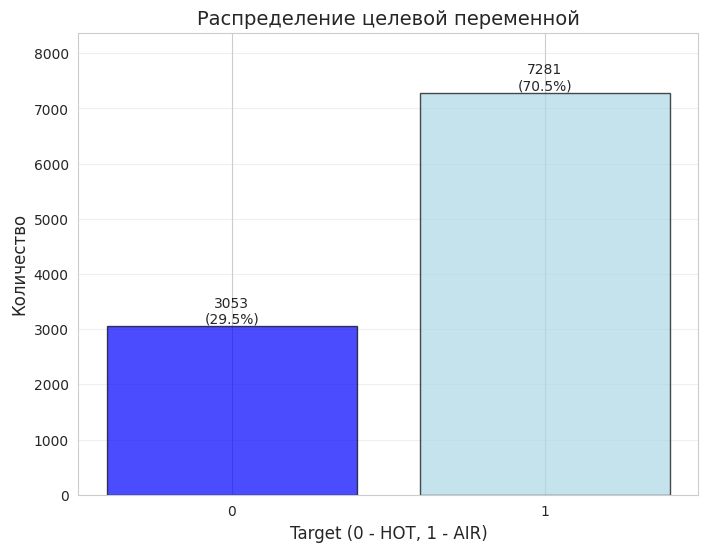

In [ ]:
# Получаем значения и проценты
target_counts = first_orders['target'].value_counts().sort_index()
target_percents = first_orders['target'].value_counts(normalize=True).sort_index() * 100

# Построение
plt.figure(figsize=(8, 6))
bars = plt.bar(target_counts.index, target_counts.values,
               color=['blue', 'lightblue'],
               edgecolor='black', alpha=0.7)

# Добавление подписей с количеством и процентом
for i, (bar, percent) in enumerate(zip(bars, target_percents.values)):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(height)}\n({percent:.1f}%)',
             ha='center', va='bottom', fontsize=10)

plt.title('Распределение целевой переменной', fontsize=14)
plt.xlabel('Target (0 - HOT, 1 - AIR)', fontsize=12)
plt.ylabel('Количество', fontsize=12)
plt.xticks([0, 1])
plt.grid(axis='y', alpha=0.3)
plt.ylim(0, max(target_counts.values) * 1.15)  # Добавляем место для подписей
plt.show()

Целевая переменная распределена не равномерно

Проверяю наличие нового столбца target

In [ ]:
first_orders.columns.tolist()

['account_rk',
 'client_rk',
 'order_rk',
 'loyalty_program_type_nm',
 'bundle_nm',
 'order_type_cd',
 'order_status_cd',
 'party_first_order_dt',
 'party_first_order_type_dt',
 'created_dttm',
 'book_start_dttm',
 'local_book_start_dttm',
 'book_end_dttm',
 'hotel_country',
 'hotel_city',
 'avia_dep_city',
 'avia_arr_city',
 'promo_code_discount_amt',
 'loyalty_accrual_rub_amt',
 'nominal_price_eur_amt',
 'nominal_price_rub_amt',
 'order_item_cnt',
 'month_beginning_balance_rub',
 'monthly_income_amt',
 'suppress_email_flg',
 'suppress_call_flg',
 'last_sms_success_flg',
 'email_valid_flg',
 'children_cnt',
 'age',
 'age_type_cd',
 'parent_meeting_region_nm',
 'delivery_region_category_cd',
 'lvn_city_nm',
 'lvn_state_nm',
 'time_zone_delta_tm',
 'time_zone_cd',
 'last_used_product_cd',
 'first_used_product_cd',
 'mobile_phone_operator_nm',
 'marital_status_cd',
 'education_level_cd',
 'birth_place',
 'gender_cd',
 'last_sms_dt',
 'last_session_dttm',
 'target']

Удаляю столбце order_type_cd. вместо него теперь столбец targer (целевая переменная)

In [ ]:
first_orders.drop(columns=['order_type_cd'], inplace=True)

In [ ]:
first_orders.columns.tolist()

['account_rk',
 'client_rk',
 'order_rk',
 'loyalty_program_type_nm',
 'bundle_nm',
 'order_status_cd',
 'party_first_order_dt',
 'party_first_order_type_dt',
 'created_dttm',
 'book_start_dttm',
 'local_book_start_dttm',
 'book_end_dttm',
 'hotel_country',
 'hotel_city',
 'avia_dep_city',
 'avia_arr_city',
 'promo_code_discount_amt',
 'loyalty_accrual_rub_amt',
 'nominal_price_eur_amt',
 'nominal_price_rub_amt',
 'order_item_cnt',
 'month_beginning_balance_rub',
 'monthly_income_amt',
 'suppress_email_flg',
 'suppress_call_flg',
 'last_sms_success_flg',
 'email_valid_flg',
 'children_cnt',
 'age',
 'age_type_cd',
 'parent_meeting_region_nm',
 'delivery_region_category_cd',
 'lvn_city_nm',
 'lvn_state_nm',
 'time_zone_delta_tm',
 'time_zone_cd',
 'last_used_product_cd',
 'first_used_product_cd',
 'mobile_phone_operator_nm',
 'marital_status_cd',
 'education_level_cd',
 'birth_place',
 'gender_cd',
 'last_sms_dt',
 'last_session_dttm',
 'target']

Сформирую список столбцов для удаления, которые не будут использоваться в модели

In [ ]:
cols_to_drop = [
    # ID
    "account_rk",
    "client_rk",
    "order_rk",

    # историия заказов
    "order_type_cd",
    "last_used_product_cd",
    "first_used_product_cd",

    # информация о заказе
    "order_status_cd",
    "created_dttm",
    "book_start_dttm",
    "local_book_start_dttm",
    "book_end_dttm",
    "hotel_country",
    "hotel_city",
    "avia_dep_city",
    "avia_arr_city",
    "order_item_cnt",
    "promo_code_discount_amt",
    "loyalty_accrual_rub_amt",
    "nominal_price_eur_amt",
    "nominal_price_rub_amt",

    # история первыйх заказов и коммуникация
    "party_first_order_dt",
    "party_first_order_type_dt",
    "last_sms_dt",
    "last_sms_success_flg",
    "last_session_dttm",

    # дублирующая информация
    "time_zone_cd"
]

Удаляю столбцы из сформированного списка

In [ ]:
first_orders = first_orders.drop(columns=cols_to_drop, errors='ignore') # удаление столбцов без ошибки, если какого-то столбца нет

провею столбцы и размер датасета после удаления столбцов

In [ ]:
print(first_orders.shape)
print(first_orders.columns)

(10334, 21)
Index(['loyalty_program_type_nm', 'bundle_nm', 'month_beginning_balance_rub',
       'monthly_income_amt', 'suppress_email_flg', 'suppress_call_flg',
       'email_valid_flg', 'children_cnt', 'age', 'age_type_cd',
       'parent_meeting_region_nm', 'delivery_region_category_cd',
       'lvn_city_nm', 'lvn_state_nm', 'time_zone_delta_tm',
       'mobile_phone_operator_nm', 'marital_status_cd', 'education_level_cd',
       'birth_place', 'gender_cd', 'target'],
      dtype='object')


In [ ]:
first_orders.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10334 entries, 211625 to 24946
Data columns (total 21 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   loyalty_program_type_nm      10287 non-null  object 
 1   bundle_nm                    6080 non-null   object 
 2   month_beginning_balance_rub  10001 non-null  float64
 3   monthly_income_amt           6917 non-null   float64
 4   suppress_email_flg           10334 non-null  int64  
 5   suppress_call_flg            10334 non-null  int64  
 6   email_valid_flg              10334 non-null  int64  
 7   children_cnt                 6520 non-null   float64
 8   age                          10334 non-null  float64
 9   age_type_cd                  10324 non-null  object 
 10  parent_meeting_region_nm     9697 non-null   object 
 11  delivery_region_category_cd  10334 non-null  object 
 12  lvn_city_nm                  5737 non-null   object 
 13  lvn_state_nm    

Проверю распределение целевой переменной после удаления столбцов.

In [ ]:
first_orders['target'].value_counts(normalize=True)

,proportion
target,
1,0.704567
0,0.295433


##Обработка выбросов и пропусков

Выделяем отдельно в целях анализа целевую перменную, числовые и категориальные признаки.

In [ ]:
# Целевую переменную исключаем
X = first_orders.drop(columns=['target'])

# Числовые признаки
num_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Категориальные признаки
cat_features = X.select_dtypes(include=['object']).columns.tolist()

print("Числовые признаки:")
print(num_features)

print("\nКатегориальные признаки:")
print(cat_features)

# Бинарные признаки
binary_features = [col for col in num_features
                   if X[col].nunique() == 2]

# Чисто числовые (не бинарные)
real_num_features = [col for col in num_features
                     if col not in binary_features]

print("\nБинарные:")
print(binary_features)

print("\nЧисловые (не бинарные):")
print(real_num_features)

Числовые признаки:
['month_beginning_balance_rub', 'monthly_income_amt', 'suppress_email_flg', 'suppress_call_flg', 'email_valid_flg', 'children_cnt', 'age']

Категориальные признаки:
['loyalty_program_type_nm', 'bundle_nm', 'age_type_cd', 'parent_meeting_region_nm', 'delivery_region_category_cd', 'lvn_city_nm', 'lvn_state_nm', 'time_zone_delta_tm', 'mobile_phone_operator_nm', 'marital_status_cd', 'education_level_cd', 'birth_place', 'gender_cd']

Бинарные:
['suppress_email_flg', 'suppress_call_flg', 'email_valid_flg']

Числовые (не бинарные):
['month_beginning_balance_rub', 'monthly_income_amt', 'children_cnt', 'age']


Анализируем пропуски

In [ ]:
print("Пропуски по столбцам (отсортировано по убыванию):")


missing_info = pd.DataFrame({
    'Пропуски': first_orders.isnull().sum(),                          # создаем датафрейм булевых значенией, True-где значение пропущено и суммируем их по каждому столбцу
    'Процент': (first_orders.isnull().sum() / len(first_orders) * 100).round(2)}) # пропуски/общее количество строк в df


missing_sorted = missing_info.sort_values('Процент', ascending=False) # сортируем по проценту пропусков (убывание)

print(missing_sorted)

# Общая информация
total_missing = missing_info['Пропуски'].sum()
total_cells = first_orders.size
print(f"Всего строк в датасете: {len(first_orders)}")
print(f"Всего пропусков: {total_missing}")
print(f"Процент пропусков в датасете: {(total_missing/total_cells*100):.2f}%")

Пропуски по столбцам (отсортировано по убыванию):
                             Пропуски  Процент
education_level_cd               6527    63.16
marital_status_cd                5763    55.77
lvn_city_nm                      4597    44.48
bundle_nm                        4254    41.17
children_cnt                     3814    36.91
monthly_income_amt               3417    33.07
lvn_state_nm                     1240    12.00
parent_meeting_region_nm          637     6.16
gender_cd                         356     3.44
month_beginning_balance_rub       333     3.22
birth_place                        67     0.65
loyalty_program_type_nm            47     0.45
mobile_phone_operator_nm           20     0.19
age_type_cd                        10     0.10
suppress_email_flg                  0     0.00
email_valid_flg                     0     0.00
age                                 0     0.00
delivery_region_category_cd         0     0.00
suppress_call_flg                   0     0.00
time_zone_

Для категорий с очень большим количество пропусков создам отдельную категорию "Неизвестно"

Если пропусков очень много, замена их на самое частое значение (моду) категориально искажает реальную картину. Замена на новую категорию "неизвестно" сохраняет честное распределение данных.

Заменяю пропуски на "Unknown" в категориальных признаках: уровень образования, семейное положение, город проживания, пакетные услуги

In [ ]:
high_na_cat = ['education_level_cd', 'marital_status_cd']

for col in high_na_cat:
    first_orders[col] = first_orders[col].fillna('Unknown')

In [ ]:
cat_mid_na = ['lvn_city_nm', 'bundle_nm']

for col in cat_mid_na:
    first_orders[col] = first_orders[col].fillna('Unknown')

Анализирую данные о количестве детей и месячный доход

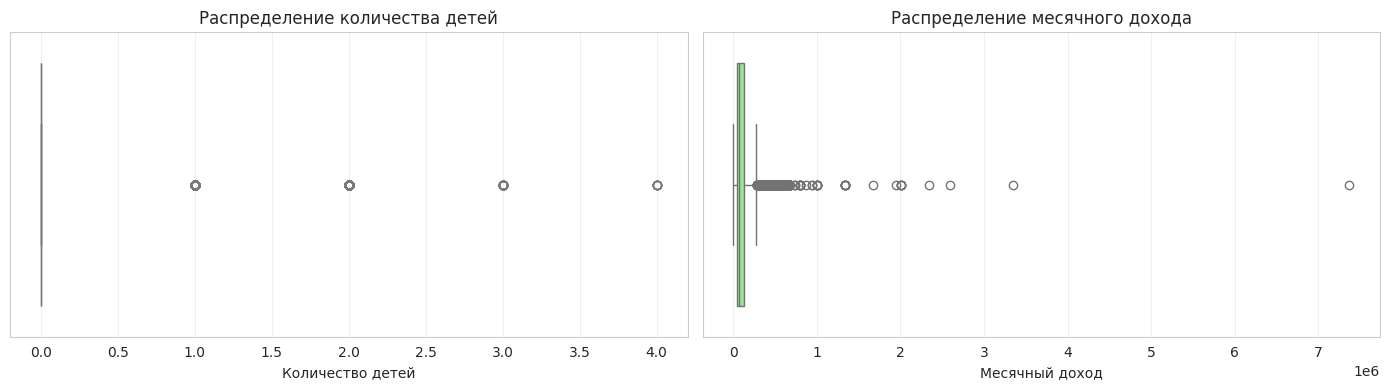

In [ ]:
# Создаем фигуру с двумя подграфиками
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Горизонтальный боксплот для количества детей
sns.boxplot(data=first_orders, x='children_cnt', ax=axes[0], color='lightblue')
axes[0].set_title('Распределение количества детей', fontsize=12)
axes[0].set_xlabel('Количество детей', fontsize=10)
axes[0].grid(axis='x', alpha=0.3)
axes[0].set_xscale('linear')  # Явно указываем линейную шкалу

# Горизонтальный боксплот для месячного дохода
sns.boxplot(data=first_orders, x='monthly_income_amt', ax=axes[1], color='lightgreen')
axes[1].set_title('Распределение месячного дохода', fontsize=12)
axes[1].set_xlabel('Месячный доход', fontsize=10)
axes[1].grid(axis='x', alpha=0.3)
axes[1].set_xscale('linear')  # Явно указываем линейную шкалу

plt.tight_layout()
plt.show()

In [ ]:
cols = ['children_cnt', 'monthly_income_amt']

first_orders[cols].describe()

,children_cnt,monthly_income_amt
count,6520.000000,6.917000e+03
mean,0.098926,1.162736e+05
std,0.419496,1.762772e+05
min,0.000000,0.000000e+00
25%,0.000000,4.020000e+04
50%,0.000000,6.700000e+04
75%,0.000000,1.340000e+05
max,4.000000,7.370066e+06


Интерпретация для children_cnt:

Большинство клиентов не имеют детей.

Признак сильно смещён в сторону нулевых значений.

Распределение является разреженным и несбалансированным.

Есть смысл рассмотреть бинаризацию признака:

0 — нет детей

1 — есть хотя бы один ребёнок

Преобразовываю столбец children_cnt в новый бинарный признак. 0 - нет детей, 1 - есть дети.

In [ ]:
first_orders['has_children'] = (first_orders['children_cnt'] > 0).astype(int) # новый бинарный столбце есть дети или нет

In [ ]:
first_orders.drop(columns=['children_cnt'], inplace=True) # старый столбце удаляю

Интерпретация для monthly_income_amt (месячный доход)

median = 67 000

mean = 116 000

mean >> median - сильная правосторонняя асимметрия

max = 7 370 066 - огромный выброс

75% клиентов <= 134 000

Несколько очень богатых клиентов искажают среднее. Это выбросы. Решение - логарифмирование. Логарифм сжимает большие значения намного сильнее, чем маленькие. Ассиметрия уменьшается, распределение становится похожим на нормальное.

Справочно, посмотрим что получится без заполнения пропусков.

In [ ]:
first_orders['monthly_income_log'] = np.log1p(first_orders['monthly_income_amt']) # log1h(x)= log(1+x) это защита от нулевых значений, если доход равен 0, то логарифм 'уйдет' в -бесконечность

In [ ]:
cols = ['monthly_income_log']

first_orders[cols].describe()

,monthly_income_log
count,6917.000000
mean,11.044969
std,1.714308
min,0.000000
25%,10.601647
50%,11.112463
75%,11.805603
max,15.812937


Сначала считаем медиану по реальным значениям, потом логарифмируем. Создаем новый столбец monthly_income_log

In [ ]:
# 1. Флаг пропуска
first_orders['monthly_income_isna'] = first_orders['monthly_income_amt'].isna().astype(int)# создание флага пропуска

# 2. Импутация
median_income = first_orders['monthly_income_amt'].median()
first_orders['monthly_income_amt'] = first_orders['monthly_income_amt'].fillna(median_income) # заполняет пропуски медианой

# 3. Лог
first_orders['monthly_income_log'] = np.log1p(first_orders['monthly_income_amt'])# логарифмирование

Проанализируем сколько в данных клиентов в нулевым доходом

In [ ]:
(first_orders['monthly_income_amt'] == 0).sum()

np.int64(110)

В данных 110 клиентов с 0 доходом. Это очень мало, влияние на модель минимально

Сделаем группировку по целевой переменной и определим среднее и медиану логарифма дохода внутри каждой группы.

In [ ]:
first_orders.groupby('target')['monthly_income_log'].median()

,monthly_income_log
target,
0,11.112463
1,11.112463


In [ ]:
first_orders.groupby('target')['monthly_income_log'].mean()

,monthly_income_log
target,
0,11.078317
1,11.062661


Значения почти одинаковые, связи между доходом и целевой переменной нет. Оба продукта одинаково интересны

Проверю предположение с помощью теста Манн-Уитни (не требует нормальности распределения)

In [ ]:
from scipy.stats import mannwhitneyu

hot = first_orders[first_orders['target'] == 0]['monthly_income_log']
air = first_orders[first_orders['target'] == 1]['monthly_income_log']

stat, p = mannwhitneyu(hot, air)
print(p)

0.2587376119668219


Статистически значимых различий нет. Доход не влияет на выбор клиента

Обработываю пропуски в lvn_state_nm (регион проживания), parent_meeting_region_nm  (региону получения банковской карты) и gender_cd (полу) меняем на "Unknown"

In [ ]:
cat_cols = ['lvn_state_nm', 'parent_meeting_region_nm']

for col in cat_cols:
    first_orders[col] = first_orders[col].fillna('Unknown')

In [ ]:
first_orders['gender_cd'] = first_orders['gender_cd'].fillna('Unknown')

Анализируем баланс в рублях на начало месяца

In [ ]:
first_orders['month_beginning_balance_rub'].describe()

,month_beginning_balance_rub
count,1.000100e+04
mean,3.088764e+04
std,1.606490e+05
min,-3.953000e+04
25%,2.570000e+02
50%,3.006000e+03
75%,1.686600e+04
max,7.234218e+06


Есть отрицательный баланс, среднее в 10 раз больше медианы. Правосторонняя асимметрия. Максимальный 7,2 млн. руб. средний остаток 30 887 р

Проанализирую сколько клиентов с отрицательным балансом

In [ ]:
# Все метрики по отрицательным значениям
negative_balances = first_orders[first_orders['month_beginning_balance_rub'] < 0]

print("=== СТАТИСТИКА ПО ОТРИЦАТЕЛЬНОМУ БАЛАНСУ ===")
print(f"Количество клиентов: {len(negative_balances)}")
print(f"Минимальное значение: {negative_balances['month_beginning_balance_rub'].min():.2f} ₽")
print(f"Максимальное значение (самое близкое к нулю): {negative_balances['month_beginning_balance_rub'].max():.2f} ₽")
print(f"Среднее значение: {negative_balances['month_beginning_balance_rub'].mean():.2f} ₽")
print(f"Медиана: {negative_balances['month_beginning_balance_rub'].median():.2f} ₽")
print(f"Стандартное отклонение: {negative_balances['month_beginning_balance_rub'].std():.2f} ₽")

=== СТАТИСТИКА ПО ОТРИЦАТЕЛЬНОМУ БАЛАНСУ ===
Количество клиентов: 205
Минимальное значение: -39530.00 ₽
Максимальное значение (самое близкое к нулю): -20.00 ₽
Среднее значение: -10644.14 ₽
Медиана: -6691.00 ₽
Стандартное отклонение: 9301.95 ₽


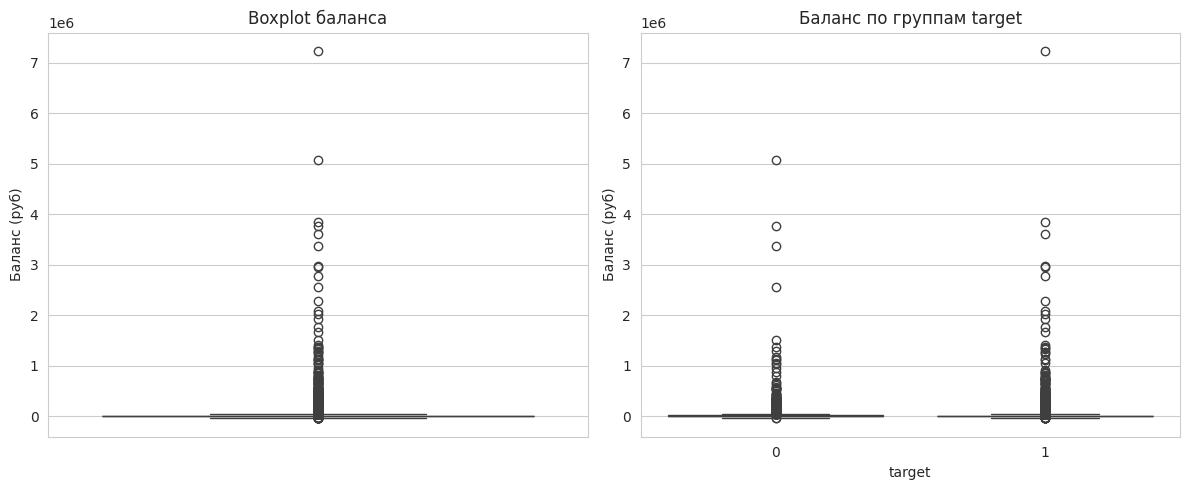

In [ ]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.boxplot(y=first_orders['month_beginning_balance_rub'])
plt.title('Boxplot баланса')
plt.ylabel('Баланс (руб)')

# Сравните с целевой переменной
plt.subplot(1, 2, 2)
sns.boxplot(x='target', y='month_beginning_balance_rub', data=first_orders)
plt.title('Баланс по группам target')
plt.xlabel('target')
plt.ylabel('Баланс (руб)')

plt.tight_layout()
plt.show()

Из-за отрицательных значений просто логарифмировать нельзя.

In [ ]:
# сначала флаг пропуска (до заполнения!)
first_orders['balance_isna'] = first_orders['month_beginning_balance_rub'].isna().astype(int)

# заполняем пропуски медианой
median_balance = first_orders['month_beginning_balance_rub'].median()
first_orders['month_beginning_balance_rub'] = first_orders['month_beginning_balance_rub'].fillna(median_balance)

# все операции с заполненными данными
first_orders['balance_negative_flag'] = (first_orders['month_beginning_balance_rub'] < 0).astype(int)
first_orders['balance_abs'] = first_orders['month_beginning_balance_rub'].abs()
first_orders['balance_abs_log'] = np.log1p(first_orders['balance_abs'])
first_orders['balance_sign'] = np.sign(first_orders['month_beginning_balance_rub'])

Для birth_place (местj рождения) пропуски меняем на "Unknown".

Для loyalty_program_type_nm (программа лояльности) пропуски меняем на "No_Program"

Для mobile_phone_operator_nm (мобильного оператора) пропуски меняем на "Unknown_Operator"

In [ ]:
# Создать индикаторы пропусков
first_orders['birth_place_isna'] = first_orders['birth_place'].isna().astype(int)
first_orders['loyalty_program_isna'] = first_orders['loyalty_program_type_nm'].isna().astype(int)
first_orders['mobile_operator_isna'] = first_orders['mobile_phone_operator_nm'].isna().astype(int)

# Заполнить пропуски модой (наиболее частым значением) или специальной меткой 'Unknown'
first_orders['birth_place'] = first_orders['birth_place'].fillna('Unknown')
first_orders['loyalty_program_type_nm'] = first_orders['loyalty_program_type_nm'].fillna('No_Program')
first_orders['mobile_phone_operator_nm'] = first_orders['mobile_phone_operator_nm'].fillna('Unknown_Operator')

Для age_type_cd (возрастной категории) пропуски заполняем модой

In [ ]:
first_orders['age_type_isna'] = first_orders['age_type_cd'].isna().astype(int)
# Заполнить наиболее частой возрастной категорией
mode_age_type = first_orders['age_type_cd'].mode()[0]
first_orders['age_type_cd'] = first_orders['age_type_cd'].fillna(mode_age_type)

Проверяем обработанный датасет на наличие пропусков.

In [ ]:
print("Пропуски по столбцам (отсортировано по убыванию):")


missing_info = pd.DataFrame({
    'Пропуски': first_orders.isnull().sum(),                          # создаем датафрейм булевых значенией, True-где значение пропущено и суммируем их по каждому столбцу
    'Процент': (first_orders.isnull().sum() / len(first_orders) * 100).round(2)}) # пропуски/общее количество строк в df


missing_sorted = missing_info.sort_values('Процент', ascending=False) # сортируем по проценту пропусков (убывание)

print(missing_sorted)

# Общая информация
total_missing = missing_info['Пропуски'].sum()
total_cells = first_orders.size
print(f"Всего строк в датасете: {len(first_orders)}")
print(f"Всего пропусков: {total_missing}")
print(f"Процент пропусков в датасете: {(total_missing/total_cells*100):.2f}%")

Пропуски по столбцам (отсортировано по убыванию):
                             Пропуски  Процент
loyalty_program_type_nm             0      0.0
bundle_nm                           0      0.0
month_beginning_balance_rub         0      0.0
monthly_income_amt                  0      0.0
suppress_email_flg                  0      0.0
suppress_call_flg                   0      0.0
email_valid_flg                     0      0.0
age                                 0      0.0
age_type_cd                         0      0.0
parent_meeting_region_nm            0      0.0
delivery_region_category_cd         0      0.0
lvn_city_nm                         0      0.0
lvn_state_nm                        0      0.0
time_zone_delta_tm                  0      0.0
mobile_phone_operator_nm            0      0.0
marital_status_cd                   0      0.0
education_level_cd                  0      0.0
birth_place                         0      0.0
gender_cd                           0      0.0
target    

In [ ]:
first_orders.isna().sum().sum()

np.int64(0)

Пропусков нет.

##Проверка силы признаков

In [ ]:
cat_features = first_orders.select_dtypes(include='object').columns.tolist() # выбираем все категориальные признаки, приобрезует в список и сохраняет в переменную
for col in cat_features:                                                             # проходит по каждому категориальному признаку из списка
    print(pd.crosstab(first_orders[col], first_orders['target'], normalize='index')) # по каждому категориальному признаку показывает распределение целевой переменной

target                                 0         1
loyalty_program_type_nm                           
AliExpress                      1.000000  0.000000
AliExpressDebit                 0.000000  1.000000
All Airlines                    0.117363  0.882637
All Airlines Premium            0.157576  0.842424
All Airlines Premium Кредитный  0.173077  0.826923
AllAirLinesDebit                0.073394  0.926606
Bravo                           0.431755  0.568245
Lamoda                          0.500000  0.500000
Lukoil                          1.000000  0.000000
No_Program                      0.127660  0.872340
S7                              0.562500  0.437500
S7 Tinkoff Premium              0.666667  0.333333
S7 Tinkoff Premium Кредитный    0.400000  0.600000
S7Debit                         0.400000  0.600000
Tinkoff Black                   0.315053  0.684947
Tinkoff Black Premium           0.350672  0.649328
Tinkoff Black Private           0.388889  0.611111
Tinkoff Black Shared           

Сильные предикторы:

Программа лояльности

Пакет услуг

Регион (некоторые города/регионы)

Оператор мобильной связи

Слабые предикторы:

Категория региона доставки

Часовой пояс (слабый тренд)

Пол (кроме Unknown)

Проблемы с данными:

Много признаков с высокой кардинальностью (тысячи уникальных значений)

Есть категории с малым количеством наблюдений (экстремальные 0/1)

Категория Unknown часто ведет себя аномально

Инсайты для бизнеса:

Молодые клиенты чаще имеют target=1

Клиенты с высоким образованием чаще имеют target=0

Определенные программы лояльности и пакеты услуг сильно коррелируют с целевой переменной

In [ ]:
print(first_orders.columns)

Index(['loyalty_program_type_nm', 'bundle_nm', 'month_beginning_balance_rub',
       'monthly_income_amt', 'suppress_email_flg', 'suppress_call_flg',
       'email_valid_flg', 'age', 'age_type_cd', 'parent_meeting_region_nm',
       'delivery_region_category_cd', 'lvn_city_nm', 'lvn_state_nm',
       'time_zone_delta_tm', 'mobile_phone_operator_nm', 'marital_status_cd',
       'education_level_cd', 'birth_place', 'gender_cd', 'target',
       'has_children', 'monthly_income_log', 'monthly_income_isna',
       'balance_isna', 'balance_negative_flag', 'balance_abs',
       'balance_abs_log', 'balance_sign', 'birth_place_isna',
       'loyalty_program_isna', 'mobile_operator_isna', 'age_type_isna'],
      dtype='object')


##Обучение модели

In [ ]:
# Целевую переменную исключаем
X = first_orders.drop(columns=['target'])

# Числовые признаки
num_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Категориальные признаки
cat_features = X.select_dtypes(include=['object']).columns.tolist()

print("Числовые признаки:")
print(num_features)

print("\nКатегориальные признаки:")
print(cat_features)

# Бинарные признаки
binary_features = [col for col in num_features
                   if X[col].nunique() == 2]

# Чисто числовые (не бинарные)
real_num_features = [col for col in num_features
                     if col not in binary_features]

print("\nБинарные:")
print(binary_features)

print("\nЧисловые (не бинарные):")
print(real_num_features)

Числовые признаки:
['month_beginning_balance_rub', 'monthly_income_amt', 'suppress_email_flg', 'suppress_call_flg', 'email_valid_flg', 'age', 'has_children', 'monthly_income_log', 'monthly_income_isna', 'balance_isna', 'balance_negative_flag', 'balance_abs', 'balance_abs_log', 'balance_sign', 'birth_place_isna', 'loyalty_program_isna', 'mobile_operator_isna', 'age_type_isna']

Категориальные признаки:
['loyalty_program_type_nm', 'bundle_nm', 'age_type_cd', 'parent_meeting_region_nm', 'delivery_region_category_cd', 'lvn_city_nm', 'lvn_state_nm', 'time_zone_delta_tm', 'mobile_phone_operator_nm', 'marital_status_cd', 'education_level_cd', 'birth_place', 'gender_cd']

Бинарные:
['suppress_email_flg', 'suppress_call_flg', 'email_valid_flg', 'has_children', 'monthly_income_isna', 'balance_negative_flag', 'birth_place_isna', 'loyalty_program_isna', 'mobile_operator_isna', 'age_type_isna']

Числовые (не бинарные):
['month_beginning_balance_rub', 'monthly_income_amt', 'age', 'monthly_income_log

Классы несбалансированы (70/30)

Это умеренный дисбаланс, не критичный, но:

Если модель всегда будет предсказывать AIR
Accuracy уже будет 70%

Почему Accuracy теперь бесполезна

Если модель покажет:

Accuracy = 72% - это почти ничего

Accuracy = 75% - уже есть небольшой сигнал

Accuracy < 70% - модель хуже константы

Поэтому метрики должны быть:

ROC-AUC

PR-AUC

F1 для HOT класса (редкий класс)

###Выбор модели

Т.к. в категориальных переменных очень много значений (особенно для географических), то буду использовать catboost, он не требует One-hot

#Обучение модели Catboost

In [ ]:
pip install catboost

In [ ]:
X = first_orders.drop(columns=['target'])
y = first_orders['target']

In [ ]:
cat_features = X.select_dtypes(include=['object', 'category']).columns.tolist()

In [ ]:
print(cat_features)

['loyalty_program_type_nm', 'bundle_nm', 'age_type_cd', 'parent_meeting_region_nm', 'delivery_region_category_cd', 'lvn_city_nm', 'lvn_state_nm', 'time_zone_delta_tm', 'mobile_phone_operator_nm', 'marital_status_cd', 'education_level_cd', 'birth_place', 'gender_cd']


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y               # сохраняем баланс классов
)

In [ ]:
from catboost import CatBoostClassifier

model = CatBoostClassifier(
    iterations=500,
    depth=6,
    learning_rate=0.05,
    eval_metric='AUC',
    random_seed=42,
    verbose=100
)

model.fit(
    X_train, y_train,
    cat_features=cat_features,
    eval_set=(X_test, y_test),
    use_best_model=True
)

0:	test: 0.6840277	best: 0.6840277 (0)	total: 156ms	remaining: 1m 17s
100:	test: 0.7821925	best: 0.7822712 (95)	total: 13.6s	remaining: 53.8s
200:	test: 0.7831514	best: 0.7834335 (165)	total: 27.3s	remaining: 40.5s
300:	test: 0.7827984	best: 0.7834335 (165)	total: 36.4s	remaining: 24.1s
400:	test: 0.7830547	best: 0.7837618 (369)	total: 41.3s	remaining: 10.2s
499:	test: 0.7838854	best: 0.7841125 (494)	total: 44.9s	remaining: 0us

bestTest = 0.784112471
bestIteration = 494

Shrink model to first 495 iterations.


CatBoostClassifier(depth=6, eval_metric='AUC', iterations=500, learning_rate=0.05, random_seed=42, verbose=100)

In [ ]:
from sklearn.metrics import roc_auc_score, average_precision_score, f1_score

y_pred_proba = model.predict_proba(X_test)[:, 1]

auc = roc_auc_score(y_test, y_pred_proba)
print("AUC:", auc)

pr_auc = average_precision_score(y_test, y_pred_proba)
print("PR-AUC:", pr_auc)

y_pred = model.predict(X_test)  # для F1 нужны предсказанные классы, а не вероятности

f1 = f1_score(y_test, y_pred, pos_label=1)
print("F1:", f1)



AUC: 0.7835965180482366
PR-AUC: 0.899038643344302
F1: 0.8399624177889132


Анализ влияющих факторов

In [ ]:
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': model.get_feature_importance()
}).sort_values(by='importance', ascending=False)

feature_importance.head(15)

,feature,importance
17,birth_place,29.749697
0,loyalty_program_type_nm,8.945350
12,lvn_state_nm,7.089208
7,age,6.687955
9,parent_meeting_region_nm,5.899481
14,mobile_phone_operator_nm,4.123320
13,time_zone_delta_tm,3.954491
16,education_level_cd,3.921521
18,gender_cd,3.649101
1,bundle_nm,3.485705


Модель демонстрирует наибольшую чувствительность к географическим характеристикам клиента, что может свидетельствовать о региональных различиях в поведении. При этом существенный вклад одного признака (birth_place) интуитивно кажется ошибочно большим. Кроме того, место рождения содержит большое количество значений, что может искажать результаты Catboost. Попробую его убрать.

In [ ]:
X2 = X.drop(columns=['birth_place'])

# дальше тот же train/test split и обучение

In [ ]:
cat_features

['loyalty_program_type_nm',
 'bundle_nm',
 'age_type_cd',
 'parent_meeting_region_nm',
 'delivery_region_category_cd',
 'lvn_city_nm',
 'lvn_state_nm',
 'time_zone_delta_tm',
 'mobile_phone_operator_nm',
 'marital_status_cd',
 'education_level_cd',
 'gender_cd']

In [ ]:
cat_features = X2.select_dtypes(include=['object', 'category']).columns.tolist()

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X2, y,
    test_size=0.2,
    random_state=42,
    stratify=y               # сохраняем баланс классов
)

In [ ]:
model = CatBoostClassifier(
    iterations=500,
    depth=6,
    learning_rate=0.05,
    eval_metric='AUC',
    random_seed=42,
    verbose=100
)

model.fit(
    X_train, y_train,
    cat_features=cat_features,
    eval_set=(X_test, y_test),
    use_best_model=True
)

0:	test: 0.6526344	best: 0.6526344 (0)	total: 32ms	remaining: 16s
100:	test: 0.7310171	best: 0.7312385 (99)	total: 3.02s	remaining: 11.9s
200:	test: 0.7334968	best: 0.7337857 (189)	total: 6.12s	remaining: 9.11s
300:	test: 0.7352920	best: 0.7360474 (281)	total: 11.3s	remaining: 7.49s
400:	test: 0.7361311	best: 0.7364413 (337)	total: 14.6s	remaining: 3.6s
499:	test: 0.7363953	best: 0.7364413 (337)	total: 17.8s	remaining: 0us

bestTest = 0.736441341
bestIteration = 337

Shrink model to first 338 iterations.


CatBoostClassifier(depth=6, eval_metric='AUC', iterations=500, learning_rate=0.05, random_seed=42, verbose=100)

In [ ]:
from sklearn.metrics import roc_auc_score, average_precision_score, f1_score

y_pred_proba = model.predict_proba(X_test)[:, 1]

auc = roc_auc_score(y_test, y_pred_proba)
print("AUC:", auc)

pr_auc = average_precision_score(y_test, y_pred_proba)
print("PR-AUC:", pr_auc)

y_pred = model.predict(X_test)  # для F1 нужны предсказанные классы, а не вероятности

f1 = f1_score(y_test, y_pred, pos_label=1)
print("F1:", f1)

AUC: 0.7364908005251704
PR-AUC: 0.8585294554639177
F1: 0.8299694189602447


Модель показывает высокое качество, особенно в контексте работы с потенциально несбалансированным набором данных:

AUC 0,74: хорошая общая способность к классификации.

PR-AUC 0,86: отличная способность находить и точно предсказывать положительные случаи.

F1 -0,83: сбалансированная и высокая производительность, подходящая для реального внедрения.

Анализ влияющих факторов

In [ ]:
import pandas as pd

feature_importance = pd.DataFrame({
    'feature': X2.columns,
    'importance': model.get_feature_importance()
}).sort_values(by='importance', ascending=False)

feature_importance.head(15)

,feature,importance
0,loyalty_program_type_nm,13.497473
12,lvn_state_nm,10.706656
7,age,8.988703
9,parent_meeting_region_nm,7.973172
14,mobile_phone_operator_nm,6.422487
16,education_level_cd,5.467306
17,gender_cd,5.306462
13,time_zone_delta_tm,5.005314
15,marital_status_cd,4.837100
8,age_type_cd,4.528442


Самыми важными факторами влияющими на выбор продукта являются программа лояльности и место проживание, далее возраст и регион получения банковской карты. При этом финансовые показатели оказывают самое слабое влияние.